## GPU Configuration and Imports <a class="anchor" id="GPU-Configuration-and-Imports"></a>

In [2]:
import os
import tensorflow as tf
import sys
import gc
print(sys.version)
print(sys.executable)
print(sys.version_info)

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0" # 0,1,2,3
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
gpus = tf.config.list_physical_devices('GPU')

print(gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Error loading GPU:", e)
# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

3.10.12 (main, Nov  4 2025, 08:48:33) [GCC 11.4.0]
/usr/bin/python3
sys.version_info(major=3, minor=10, micro=12, releaselevel='final', serial=0)
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-01-13 11:39:17.909547: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13 11:39:17.980917: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13 11:39:17.980984: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# Import Sionna
try:
    import sionna
except ImportError as e:
    # Install Sionna if package is not already installed
    import os
    os.system("pip install sionna")
    import sionna

sionna.phy.config.seed = 42 # Set seed for reproducible random number generation

2026-01-13 11:39:18.972166: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13 11:39:18.972251: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13 11:39:18.972270: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13 11:39:19.099692: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:55:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-01-13 11:39:19.099775: I external/local_xla/xla/stream_executor

In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pickle

from tensorflow.keras import Model
from tensorflow.keras.layers import Layer, Conv2D, LayerNormalization, Dense, ReLU, PReLU, Reshape, Conv2DTranspose, LeakyReLU, Flatten
from tensorflow.nn import relu
from tensorflow.keras.models import Sequential

from sionna.phy.channel.tr38901 import Antenna, AntennaArray, CDL
from sionna.phy.channel import OFDMChannel, RayleighBlockFading, GenerateOFDMChannel
from sionna.phy.mimo import StreamManagement
from sionna.phy.ofdm import ResourceGrid, ResourceGridMapper, LSChannelEstimator, LMMSEEqualizer, RemoveNulledSubcarriers, ResourceGridDemapper, LMMSEInterpolator
from sionna.phy.utils import ebnodb2no, insert_dims, flatten_last_dims, log10, expand_to_rank
from sionna.phy.fec.ldpc.encoding import LDPC5GEncoder
from sionna.phy.fec.ldpc.decoding import LDPC5GDecoder
from sionna.phy.mapping import BinarySource, Mapper, Demapper, Constellation
from sionna.phy.utils.metrics import compute_ber
from sionna.phy.utils import sim_ber, hard_decisions

from tqdm.auto import tqdm

## Simulation Parameters <a class="anchor" id="Simulation-Parameters"></a>

In [5]:
# ## Channel configuration
carrier_frequency = 3.5e9 # Hz
cdl_model = "C" # CDL model to use
delay_spread = 100e-9 # s
speed = 10.0 # Speed for evaluation and training [m/s]
# Ultra-high coherence channel
# delay_spread = 10e-9  # 10 ns → Bc ≈ 16 MHz
# speed = 0.1  # 0.1 m/s → Tc ≈ 428 ms

# SNR range for evaluation and training [dB]
ebno_db_min = 0.0
ebno_db_max = 15.0

############################################
## OFDM waveform configuration
subcarrier_spacing = 30e3 # Hz
fft_size = 128 # Number of subcarriers forming the resource grid, including the null-subcarrier and the guard bands
num_ofdm_symbols = 14 # Number of OFDM symbols forming the resource grid
dc_null = True # Null the DC subcarrier
num_guard_carriers = [5, 6] # Number of guard carriers on each side
pilot_pattern = "kronecker" # Pilot pattern
pilot_ofdm_symbol_indices = [2, 11] # Index of OFDM symbols carrying pilots
cyclic_prefix_length = 0 # Simulation in frequency domain. This is useless

############################################
## Modulation and coding configuration
num_bits_per_symbol = 6 # 64-QAM
coderate = 0.5 # 0.5 # Coderate for LDPC code
noise_dim = 100

############################################
## Neural receiver configuration
num_conv_channels = 128 # Number of convolutional channels for the convolutional layers forming the neural receiver
GAN_DIM=64

############################################
## Training configuration
num_training_iterations = 30000 # Number of training iterations
batch_size = 128 # Training batch size

############################################
## Evaluation configuration
results_filename = "neural_receiver_results" # Location to save the results

In [6]:
stream_manager = StreamManagement(np.array([[1]]), # Receiver-transmitter association matrix
                                  1)               # One stream per transmitter

2026-01-13 11:39:19.464126: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Subcarrier spacing: 30000.0 Hz
OFDM symbol duration: 3.3333333333333335e-05 s
Pilot pattern: <sionna.phy.ofdm.pilot_pattern.KroneckerPilotPattern object at 0x79a3e7a8f1c0>
Pilot spacing in time: every 14 symbols
Pilots per symbol: 232


[<Figure size 640x480 with 2 Axes>]

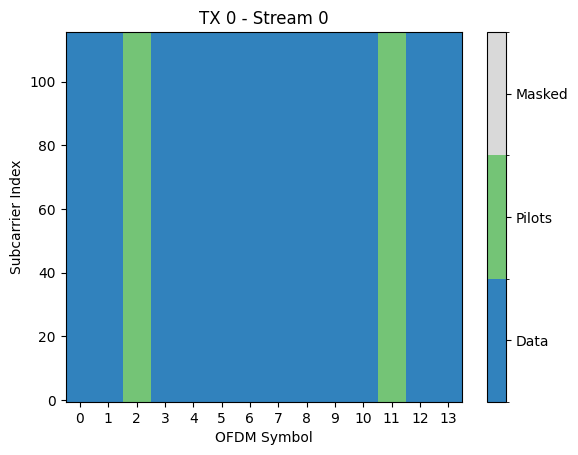

In [7]:
resource_grid = ResourceGrid(num_ofdm_symbols = num_ofdm_symbols,
                             fft_size = fft_size,
                             subcarrier_spacing = subcarrier_spacing,
                             num_tx = 1,
                             num_streams_per_tx = 1,
                             cyclic_prefix_length = cyclic_prefix_length,
                             dc_null = dc_null,
                             pilot_pattern = pilot_pattern,
                             pilot_ofdm_symbol_indices = pilot_ofdm_symbol_indices,
                             num_guard_carriers = num_guard_carriers)
# resource_grid.show()
print(f"Subcarrier spacing: {resource_grid.subcarrier_spacing} Hz")
print(f"OFDM symbol duration: {resource_grid.ofdm_symbol_duration} s")
print(f"Pilot pattern: {resource_grid.pilot_pattern}")
print(f"Pilot spacing in time: every {resource_grid.pilot_pattern.num_ofdm_symbols} symbols")
print(f"Pilots per symbol: {resource_grid.pilot_pattern.num_pilot_symbols}")
resource_grid.pilot_pattern.show()

In [8]:
# Codeword length. It is calculated from the total number of databits carried by the resource grid, and the number of bits transmitted per resource element
# data symbols = 1392
n = int(resource_grid.num_data_symbols*num_bits_per_symbol)
# Number of information bits per codeword
k = int(n*coderate)
print(n)
print(k)

8352
4176


In [9]:
ut_antenna = Antenna(polarization="single",
                     polarization_type="V",
                     antenna_pattern="38.901",
                     carrier_frequency=carrier_frequency)

bs_array = AntennaArray(num_rows=1,
                        num_cols=1,
                        polarization="single", # dual
                        polarization_type="V", # VH
                        antenna_pattern="38.901",
                        carrier_frequency=carrier_frequency)

### Resource Grid Util

In [10]:
class ModifiedResourceGridMapper(Layer):
    def __init__(self, resource_grid, dtype=tf.complex64, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots
        self._data_ind = tf.where(self._rg_type == 0)   # Indices for data
    
    def extract_pilots(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        
        pilot_grid = tf.zeros_like(input_rg)
        pilot_values = tf.gather_nd(input_rg, self._pilot_ind)
        pilot_grid = tf.tensor_scatter_nd_update(pilot_grid, self._pilot_ind, pilot_values)
        
        pilot_grid = tf.expand_dims(pilot_grid, axis=1)
        
        return pilot_grid
    
    def extract_data(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        
        data_grid = tf.zeros_like(input_rg)
        data_values = tf.gather_nd(input_rg, self._data_ind)
        data_grid = tf.tensor_scatter_nd_update(data_grid, self._data_ind, data_values)
        
        data_grid = tf.expand_dims(data_grid, axis=1)
        
        return data_grid
    
    def extract_data_symbols_only(self, input_rg):
        input_rg = tf.squeeze(input_rg, axis=1)
        data_values = tf.gather_nd(input_rg, self._data_ind)  # [batch, num_rx, num_data_symbols]
        data_values = tf.expand_dims(data_values, axis=1)  # [batch, 1, num_rx, num_data_symbols]
        return data_values
    
    def replace(self, inputs):
        # Unpack the generated and real resource grids
        generated_y_rg, real_y_rg = inputs  # (batch, 1, 2, ofdm, subcar)
        generated_y_rg = tf.squeeze(generated_y_rg, axis=1)
        real_y_rg = tf.squeeze(real_y_rg, axis=1)
        
        # Extract the pilots from the real resource grid
        real_pilots = tf.gather_nd(real_y_rg, self._pilot_ind)
        
        # Replace the pilots in the generated resource grid with the real pilots
        updated_y_rg = tf.tensor_scatter_nd_update(generated_y_rg, self._pilot_ind, real_pilots)
        updated_y_rg = tf.expand_dims(updated_y_rg, axis=1)  # Restore dimensions
        
        return updated_y_rg


# resource grid helper
rg_util = ModifiedResourceGridMapper(resource_grid)

In [11]:
@tf.function
def add_nulled_subcarriers(h_hat_active):
        """
        Add nulled subcarriers back to channel estimate.
        h_hat_active has shape (batch, 1, 1, 14, 116)
        Returns tensor with shape (batch, 1, 1, 14, 128)
        
        This method is integrated directly into the model to ensure proper gradient flow.
        """
        # Get dynamic batch size
        batch_size = tf.shape(h_hat_active)[0]
        
        # Split the 116 active subcarriers into two groups
        h_before_dc = h_hat_active[:, :, :, :, :59]   # First 59 (positions 5-63)
        h_after_dc = h_hat_active[:, :, :, :, 59:]    # Last 57 (positions 65-121)
        
        # Create zero tensors for guard bands and DC
        dtype = h_hat_active.dtype
        zeros_guard_low = tf.zeros([batch_size, 1, 1, 14, 5], dtype=dtype)    # Positions 0-4
        zeros_dc = tf.zeros([batch_size, 1, 1, 14, 1], dtype=dtype)           # Position 64 (DC)
        zeros_guard_high = tf.zeros([batch_size, 1, 1, 14, 6], dtype=dtype)   # Positions 122-127
        
        # Concatenate in the correct order: [0-4][5-63][64][65-121][122-127]
        h_hat_full = tf.concat([
            zeros_guard_low,    # Positions 0-4 (5 zeros)
            h_before_dc,        # Positions 5-63 (59 subcarriers) 
            zeros_dc,           # Position 64 (1 zero - DC)
            h_after_dc,         # Positions 65-121 (57 subcarriers)
            zeros_guard_high    # Positions 122-127 (6 zeros)
        ], axis=-1)
        
        return h_hat_full

### Neural Receiver <a class="anchor" id="Neural-Receiver"></a>

In [12]:
class ResidualBlock(Layer):
    def __init__(self, name=None, **kwargs):
        super(ResidualBlock, self).__init__(name=name, **kwargs)
    
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_1 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_1 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)
        # Layer normalization is done over the last three dimensions: time, frequency, conv 'channels'
        self._layer_norm_2 = LayerNormalization(axis=(-1, -2, -3))
        self._conv_2 = Conv2D(filters=num_conv_channels,
                              kernel_size=[3,3],
                              padding='same',
                              activation=None)

    def call(self, inputs):
        z = self._layer_norm_1(inputs)
        z = relu(z)
        z = self._conv_1(z)
        z = self._layer_norm_2(z)
        z = relu(z)
        z = self._conv_2(z) # [batch size, num time samples, num subcarriers, num_channels]
        # Skip connection
        z = z + inputs

        return z

In [13]:
class NeuralReceiver(Model):
    def __init__(self, **kwargs):
        super(NeuralReceiver, self).__init__(**kwargs)
        self.receiver = self.build_receiver()
    
    def build_receiver(self):
        self._input_conv = Conv2D(filters=num_conv_channels,
                                  kernel_size=[3,3],
                                  padding='same',
                                  activation=None,
                                 name="neural_receiver_input_conv")
        self._output_conv = Conv2D(filters=num_bits_per_symbol,
                                   kernel_size=[3,3],
                                   padding='same',
                                   activation=None,
                                  name="neural_receiver_output_conv")

        # 2*Nt (pilots) + 2*Nr (rx data) + 2*Nr*Nt (channel est)
        # total channels = 2*Nt + 2*Nr + 2*Nr*Nt (real+imag)
        inputs = tf.keras.Input(shape=(14, 128, 2*1 + 2*1 + 2*1*1))
        
        # Input conv
        z = self._input_conv(inputs)
        # Residual blocks
        z = ResidualBlock(name="neural_receiver_residual_block_1")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_2")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_3")(z)
        z = ResidualBlock(name="neural_receiver_residual_block_4")(z)
        # Output conv
        z = self._output_conv(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_receiver")

    def call(self, inputs):
        y, x_p, h_hat = inputs
        
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0, 2, 3, 1]) # [batch, ofdm, subcar, Nr]
        y_real_imag = tf.concat([tf.math.real(y), tf.math.imag(y)], axis=-1)  # [batch, ofdm, subcar, 2*Nr]
        
        x_p = tf.squeeze(x_p, axis=2)
        x_p = tf.transpose(x_p, [0, 2, 3, 1]) # [batch, ofdm, subcar, Nt]
        x_real_imag = tf.concat([tf.math.real(x_p), tf.math.imag(x_p)], axis=-1)  # [batch, ofdm, subcar, 2*Nt]
        
        h_hat = tf.transpose(h_hat, [0, 3, 4, 1, 2]) # [batch, ofdm, subcar, Nt, Nr]
        h_hat = tf.reshape(h_hat, [tf.shape(h_hat)[0], tf.shape(h_hat)[1], tf.shape(h_hat)[2], -1]) # [batch, ofdm, subcar, Nr*Nt]
        h_real_imag = tf.concat([tf.math.real(h_hat), tf.math.imag(h_hat)], axis=-1)  # [batch, ofdm, subcar, 2*Nr*Nt]
        
        # z: [batch, ofdm, subcar, 2*Nr+2*Nt+2*Nr*Nt]
        z = tf.concat([y_real_imag, x_real_imag, h_real_imag], axis=-1)
        
        z = self.receiver(z)
        
        return z

In [14]:
NR = NeuralReceiver()
NR.receiver.summary()

Model: "Neural_receiver"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 14, 128, 6)]      0         
                                                                 
 neural_receiver_input_conv  (None, 14, 128, 128)      7040      
  (Conv2D)                                                       
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_1 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_2 (ResidualBlock)                                          
                                                                 
 neural_receiver_residual_b  (None, 14, 128, 128)      1212672   
 lock_3 (ResidualBlock)                            

#### Hybrid Receiver (Neural demapper)

In [25]:
class NeuralDemapper(Model):
    """Neural network for demapping"""
    def __init__(self, num_bits_per_symbol, **kwargs):
        super(NeuralDemapper, self).__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        self.demapper = self.build_demapper()
    
    def build_demapper(self):
        # input: [real, imag, noise]
        input_dim = 3
        inputs = tf.keras.Input(shape=(None, input_dim))
        
        z = tf.keras.layers.Dense(128, activation='relu')(inputs)
        z = tf.keras.layers.Dense(128, activation='relu')(z)
        z = tf.keras.layers.Dense(self.num_bits_per_symbol, activation=None)(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="Neural_demapper")
    
    def call(self, x_eq, no_eff):
        x_eq = tf.squeeze(x_eq, axis=[1, 2])  # [batch, num_data_symbols]
        no_eff = tf.squeeze(no_eff, axis=[1, 2])  # [batch, num_data_symbols]
        
        x_real = tf.math.real(x_eq)
        x_imag = tf.math.imag(x_eq)
        
        # Stack: [real, imag, noise]
        x_input = tf.stack([x_real, x_imag, no_eff], axis=-1)  # [batch, num_data_symbols, 3]
        
        llrs = self.demapper(x_input)  # [batch, num_data_symbols, num_bits_per_symbol]
        
        # Flatten to [batch, num_data_symbols * num_bits_per_symbol]
        llrs = tf.reshape(llrs, [tf.shape(llrs)[0], -1])
        
        return llrs


class HybridReceiver(Model):
    """LS + LMMSE Equalization + Neural Demapping"""
    def __init__(self, resource_grid, stream_manager, num_bits_per_symbol, **kwargs):
        super(HybridReceiver, self).__init__(**kwargs)
        
        self.ls_estimator = LSChannelEstimator(resource_grid, interpolation_type="nn")
        self.lmmse_equalizer = LMMSEEqualizer(resource_grid, stream_manager)
        self.neural_demapper = NeuralDemapper(num_bits_per_symbol)
    
    def call(self, inputs):
        y, no = inputs
        
        # LS channel estimation
        h_hat, err_var = self.ls_estimator(y, no)
        
        # LMMSE equalization 
        x_eq, no_eff = self.lmmse_equalizer(y, h_hat, err_var, no)
        
        # Neural demapping (single pass, no feedback)
        llrs = self.neural_demapper(x_eq, no_eff)  # [batch, n]
        
        return llrs

In [26]:
HR = HybridReceiver(
    resource_grid=resource_grid,
    stream_manager=stream_manager,
    num_bits_per_symbol=num_bits_per_symbol)
HR.neural_demapper.demapper.summary()

Model: "Neural_demapper"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, None, 3)]         0         
                                                                 
 dense (Dense)               (None, None, 128)         512       
                                                                 
 dense_1 (Dense)             (None, None, 128)         16512     
                                                                 
 dense_2 (Dense)             (None, None, 6)           774       
                                                                 
Total params: 17798 (69.52 KB)
Trainable params: 17798 (69.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


#### Hybrid Receiver (Neural equalizer+demapper)

In [27]:
class NeuralEqualizerDemapper(Model):
    """Neural network for joint equalization and demapping"""
    def __init__(self, num_bits_per_symbol, resource_grid, **kwargs):
        super(NeuralEqualizerDemapper, self).__init__(**kwargs)
        self.num_bits_per_symbol = num_bits_per_symbol
        
        # Precompute data indices from resource grid
        rg_type = resource_grid.build_type_grid()  # [1, num_rx, ofdm, subcar]
        rg_type = tf.squeeze(rg_type, axis=[0, 1])  # [ofdm, subcar]
        self._data_ind = tf.where(rg_type == 0)  # [num_data, 2]
        self.num_data_symbols = tf.shape(self._data_ind)[0]
        
        self.equalizer_demapper = self.build_equalizer_demapper()
    
    def build_equalizer_demapper(self):
        """Build neural network for joint equalization and demapping"""
        # Input: [y_real, y_imag, h_real, h_imag, err_var]
        input_dim = 5
        inputs = tf.keras.Input(shape=(None, input_dim))
        
        z = tf.keras.layers.Dense(256, activation='relu')(inputs)
        z = tf.keras.layers.Dense(256, activation='relu')(z)
        z = tf.keras.layers.Dense(128, activation='relu')(z)
        z = tf.keras.layers.Dense(self.num_bits_per_symbol, activation=None)(z)
        
        return tf.keras.Model(inputs=inputs, outputs=z, name="neural_equalizer_demapper")
    
    def call(self, y, h_hat, err_var):
        batch_size = tf.shape(y)[0]
        
        # Squeeze to [batch, num_rx, ofdm, subcar]
        y = tf.squeeze(y, axis=1)
        h_hat = tf.squeeze(h_hat, axis=[1,2,3])
        err_var = tf.squeeze(err_var, axis=[1,2,3])
        y = y[:, 0, :, :]  # [batch, ofdm, subcar]
        h_hat = h_hat[:, 0, :, :]
        err_var = err_var[:, 0, :, :]
        
        # Extract data positions for each batch
        def extract_data_per_batch(inputs):
            y_sample, h_sample, err_sample = inputs
            # Each: [ofdm, subcar]
            
            y_data = tf.gather_nd(y_sample, self._data_ind)  # [num_data]
            h_data = tf.gather_nd(h_sample, self._data_ind)
            err_data = tf.gather_nd(err_sample, self._data_ind)
            
            # Stack features
            y_real = tf.math.real(y_data)
            y_imag = tf.math.imag(y_data)
            h_real = tf.math.real(h_data)
            h_imag = tf.math.imag(h_data)
            
            features = tf.stack([y_real, y_imag, h_real, h_imag, err_data], axis=-1)
            return features  # [num_data, 5]
        
        x_input = tf.map_fn(
            extract_data_per_batch,
            (y, h_hat, err_var),
            fn_output_signature=tf.TensorSpec(shape=(None, 5), dtype=tf.float32)
        )  # [batch, num_data, 5]
        
        # Pass through neural network
        llrs = self.equalizer_demapper(x_input)  # [batch, num_data, num_bits_per_symbol]
        
        # Flatten to [batch, num_data * num_bits_per_symbol]
        llrs = tf.reshape(llrs, [batch_size, -1])
        
        return llrs


class HybridReceiver(Model):
    """LS Channel Estimation + Neural Equalization and Demapping"""
    def __init__(self, resource_grid, stream_manager, num_bits_per_symbol, **kwargs):
        super(HybridReceiver, self).__init__(**kwargs)
        
        self.ls_estimator = LSChannelEstimator(resource_grid, interpolation_type="nn")
        self.neural_equalizer_demapper = NeuralEqualizerDemapper(
            num_bits_per_symbol, 
            resource_grid
        )
        self.resource_grid = resource_grid
        self.stream_manager = stream_manager
    
    def call(self, inputs):
        y, no = inputs
        
        # LS channel estimation
        h_hat, err_var = self.ls_estimator([y, no])
        
        # Neural equalization and demapping
        llrs = self.neural_equalizer_demapper(y, h_hat, err_var)
        
        return llrs

In [28]:
HR = HybridReceiver(
    resource_grid=resource_grid,
    stream_manager=stream_manager,
    num_bits_per_symbol=num_bits_per_symbol)
HR.neural_equalizer_demapper.equalizer_demapper.summary()

Model: "neural_equalizer_demapper"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, None, 5)]         0         
                                                                 
 dense_3 (Dense)             (None, None, 256)         1536      
                                                                 
 dense_4 (Dense)             (None, None, 256)         65792     
                                                                 
 dense_5 (Dense)             (None, None, 128)         32896     
                                                                 
 dense_6 (Dense)             (None, None, 6)           774       
                                                                 
Total params: 100998 (394.52 KB)
Trainable params: 100998 (394.52 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Conv2D GAN

In [15]:
class GANGenerator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANGenerator, self).__init__(**kwargs)
        self.generator = self.build_generator()

    def build_generator(self):
        """Builds the generator model."""
        x_real_input = tf.keras.layers.Input(shape=(14,128,2))  # (batch,14,128,2)
        noise_input = tf.keras.layers.Input(shape=(14,128,noise_dim)) 
        c_input = tf.keras.layers.Input(shape=(14,128,4))  # (batch,14,128,2) or (batch,14,128,4) for pilots
        
        x = tf.keras.layers.Concatenate()([x_real_input, noise_input, c_input])

        x = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        x = tf.keras.layers.ReLU()(x)
        
        skip_processed = tf.keras.layers.Conv2D(256, (1,1), padding='same')(x_real_input)
        x = tf.keras.layers.Add()([x, skip_processed])

        x = tf.keras.layers.Conv2D(filters=2, kernel_size=(3, 3), padding='same', use_bias=False)(x)
        
        return  tf.keras.Model(inputs=[x_real_input, noise_input, c_input], outputs=x, name="GANChannel_Generator")
    
    def call(self, z, x, extra_condition):
        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1])
        x_real, x_imag = tf.math.real(x), tf.math.imag(x) # [batch,14,128,ant]
        x_flat = tf.concat([x_real, x_imag], axis=-1) #  [batch,14,128,2*ant]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1])
        c_real, c_imag = tf.math.real(c), tf.math.imag(c) # [batch,14,128,ant]
        c_flat = tf.concat([c_real, c_imag], axis=-1) #  [batch,14,128,2*ant]
        
        y = self.generator([x_flat, z, c_flat]) # [batch,14,128,2]
        
        batch_size = tf.shape(y)[0]
        y = tf.reshape(y, (batch_size, 14, 128, 2, 1))

        y_r = y[:, :, :, 0, :]  # (batch, 14, 128, rx_ant)
        y_i = y[:, :, :, 1, :]  # (batch, 14, 128, rx_ant) 
        y_r = tf.transpose(y_r, [0, 3, 1, 2])  # (batch, rx_ant, 14, 128)
        y_i = tf.transpose(y_i, [0, 3, 1, 2])  # (batch, rx_ant, 14, 128)
        y_complex = tf.complex(y_r, y_i)
        
        y_complex = tf.expand_dims(y_complex, axis=1)
        
        return y_complex


In [16]:
gan_generator = GANGenerator()
gan_generator.generator.summary()

Model: "GANChannel_Generator"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 14, 128, 2)]         0         []                            
                                                                                                  
 input_3 (InputLayer)        [(None, 14, 128, 100)]       0         []                            
                                                                                                  
 input_4 (InputLayer)        [(None, 14, 128, 4)]         0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 14, 128, 106)         0         ['input_2[0][0]',             
                                                                     'input_3[0

In [17]:
class GANDiscriminator(tf.keras.Model):
    def __init__(self, **kwargs):
        super(GANDiscriminator, self).__init__(**kwargs)
        self.discriminator = self.build_discriminator()
    
    def build_discriminator(self):
        """Builds the discriminator model."""
        y_rg = tf.keras.layers.Input(shape=(14,128,8)) # 14,128,6 or 14,128,8 for pilots

        y = tf.keras.layers.Conv2D(filters=64, kernel_size=(3, 3), padding='same')(y_rg)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=128, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)
        y = tf.keras.layers.Conv2D(filters=256, kernel_size=(3, 3), padding='same')(y)
        # y = tf.keras.layers.LayerNormalization()(y)
        y = tf.keras.layers.LeakyReLU()(y)
        # y = tf.keras.layers.Dropout(0.3)(y)

        # y = tf.keras.layers.Flatten()(y)
        # # FC = tf.nn.relu(tf.keras.layers.Dense(100, activation=None)(FC))
        # D_logit = tf.keras.layers.Dense(1, activation='linear')(y) # sigmoid
        # # D_prob = tf.nn.sigmoid(conv4)
        
        y = tf.keras.layers.GlobalAveragePooling2D()(y)
        y = tf.keras.layers.Dense(128)(y)
        D_logit = tf.keras.layers.Dense(1, activation='linear')(y)
        
        return tf.keras.Model(inputs=y_rg, outputs=D_logit, name="GANChannel_Discriminator")
    
    def call(self, y, x, extra_condition):
        y = tf.squeeze(y, axis=1)
        y = tf.transpose(y, [0,2,3,1])
        y_real, y_imag = tf.math.real(y), tf.math.imag(y) # [batch,14,128,ant]
        y_cat = tf.concat([y_real, y_imag], axis=-1) # [batch,14,128,2*ant]

        x = tf.squeeze(x, axis=1)
        x = tf.transpose(x, [0,2,3,1])
        x_real, x_imag = tf.math.real(x), tf.math.imag(x) # [batch,14,128,ant]
        x_cat = tf.concat([x_real, x_imag], axis=-1) # [batch,14,128,2*ant]

        c = tf.squeeze(extra_condition, axis=1)
        c = tf.transpose(c, [0,2,3,1])
        c_real, c_imag = tf.math.real(c), tf.math.imag(c) # [batch,14,128,ant]
        c_cat = tf.concat([c_real, c_imag], axis=-1) #  [batch,14,128,2*ant]
        
        cat = tf.concat([y_cat, x_cat, c_cat], axis=-1) # [batch,14,128,c]

        y_logit = self.discriminator(cat)
        
        return y_logit


In [18]:
gan_discriminator = GANDiscriminator()
gan_discriminator.discriminator.summary()

Model: "GANChannel_Discriminator"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 14, 128, 8)]      0         
                                                                 
 conv2d_13 (Conv2D)          (None, 14, 128, 64)       4672      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 128, 64)       0         
                                                                 
 conv2d_14 (Conv2D)          (None, 14, 128, 128)      73856     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 14, 128, 128)      0         
                                                                 
 conv2d_15 (Conv2D)          (None, 14, 128, 256)      295168    
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 14, 12

## End-to-end System <a class="anchor" id="End-to-end-System"></a>

In [ ]:
n_sample = int(resource_grid.num_data_symbols*num_bits_per_symbol)

def sample_channel(batch_size, snr_db):
    # Create OFDM resource grid
    binary_source = BinarySource()
    rg_mapper = ResourceGridMapper(resource_grid)
    mapper = Mapper("qam", num_bits_per_symbol)
    c = binary_source([batch_size, 1, resource_grid.num_streams_per_tx, n_sample])
    x = mapper(c)
    x_rg = rg_mapper(x)  # OFDM modulated symbols

    ## CDL Channel
    cdl = CDL(cdl_model, delay_spread, carrier_frequency,
              ut_antenna, bs_array, "uplink", min_speed=speed)
    # rayleigh = RayleighBlockFading(num_rx=1, num_rx_ant=2, num_tx=1, num_tx_ant=1)
    channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

    # noise
    ebno_db = tf.constant(10.0, tf.float32)
    no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
    no_ = expand_to_rank(no, tf.rank(x_rg))

    y, H = channel([x_rg, no_])
    
    return y, H, x, x_rg, no_


In [ ]:
FFT_SIZE = 128
NUM_OFDM_SYMBOLS = 14
NUM_RX_ANT = 1

def estimate_covariance_matrices(num_it, batch_size):
    # Initialize accumulators
    freq_cov_mat = tf.zeros([FFT_SIZE, FFT_SIZE], tf.complex64)
    time_cov_mat = tf.zeros([NUM_OFDM_SYMBOLS, NUM_OFDM_SYMBOLS], tf.complex64)
    space_cov_mat = tf.ones([NUM_RX_ANT, NUM_RX_ANT], tf.complex64)  # Identity for SISO
    
    total_samples = 0
    
    for i in range(num_it):
        y, h_freq, x_real, x_rg, no_ = sample_channel(batch_size, 10)  # Use a moderate SNR
        
        # Process each sample individually to avoid OOM
        for b in range(batch_size):
            # Extract single channel realization [14, 128]
            h_sample = h_freq[b, 0, 0, 0, 0, :, :]
            
            # For frequency covariance - transpose to get [128, 14]
            h_freq_view = tf.transpose(h_sample)
            # Compute outer product for frequency covariance
            freq_cov_update = tf.matmul(h_freq_view, h_freq_view, adjoint_b=True)
            
            # For time covariance - use [14, 128]
            time_cov_update = tf.matmul(h_sample, h_sample, adjoint_b=True)
            
            # Update accumulators
            freq_cov_mat += freq_cov_update
            time_cov_mat += time_cov_update
            total_samples += 1
    
    # Normalize by total number of samples
    freq_cov_mat /= tf.cast(total_samples, tf.complex64)
    time_cov_mat /= tf.cast(total_samples, tf.complex64)
    
    # Check if values are reasonable (add this for debugging)
    print("Frequency covariance diagonal mean:", 
          tf.reduce_mean(tf.linalg.diag_part(tf.abs(freq_cov_mat))))
    print("Frequency covariance off-diagonal mean:", 
          tf.reduce_mean(tf.abs(freq_cov_mat)) - 
          tf.reduce_mean(tf.linalg.diag_part(tf.abs(freq_cov_mat))))
    
    return freq_cov_mat, time_cov_mat, space_cov_mat

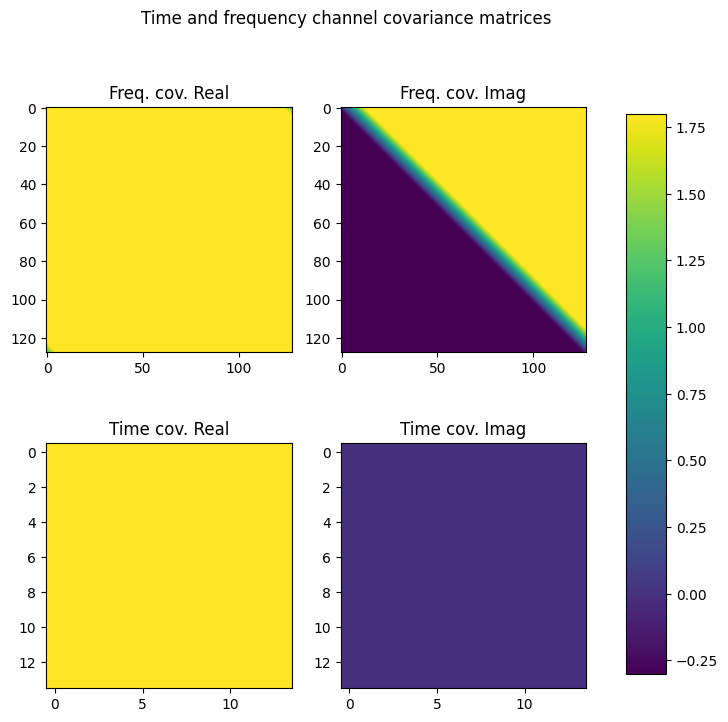

In [ ]:
FREQ_COV_MAT = np.load('freq_cov_mat.npy')
TIME_COV_MAT = np.load('time_cov_mat.npy')
SPACE_COV_MAT = np.load('space_cov_mat.npy')

fig, ax = plt.subplots(2,2, figsize=(8,8))
fig.suptitle("Time and frequency channel covariance matrices")

ax[0,0].set_title("Freq. cov. Real")
im = ax[0,0].imshow(FREQ_COV_MAT.real, vmin=-0.3, vmax=1.8)
ax[0,1].set_title("Freq. cov. Imag")
im = ax[0,1].imshow(FREQ_COV_MAT.imag, vmin=-0.3, vmax=1.8)

ax[1,0].set_title("Time cov. Real")
im = ax[1,0].imshow(TIME_COV_MAT.real, vmin=-0.3, vmax=1.8)
ax[1,1].set_title("Time cov. Imag")
im = ax[1,1].imshow(TIME_COV_MAT.imag, vmin=-0.3, vmax=1.8)

# ax[2,0].set_title("Space cov. Real")
# im = ax[2,0].imshow(SPACE_COV_MAT.real, vmin=-0.3, vmax=1.8)
# ax[2,1].set_title("Space cov. Imag")
# im = ax[2,1].imshow(SPACE_COV_MAT.imag, vmin=-0.3, vmax=1.8)

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax);


In [21]:
FREQ_COV_MAT = np.load('freq_cov_mat.npy')
TIME_COV_MAT = np.load('time_cov_mat.npy')
SPACE_COV_MAT = np.load('space_cov_mat.npy')
freq_cov_mat = tf.constant(FREQ_COV_MAT, tf.complex64)
time_cov_mat = tf.constant(TIME_COV_MAT, tf.complex64)

active_mask = tf.concat([
   tf.zeros(num_guard_carriers[0], dtype=tf.bool),
   tf.ones(fft_size - num_guard_carriers[0] - num_guard_carriers[1] - 1, dtype=tf.bool),
   tf.zeros(1, dtype=tf.bool),  # DC
   tf.ones(0, dtype=tf.bool) if num_guard_carriers[1] == 0 else tf.zeros(num_guard_carriers[1], dtype=tf.bool)
], axis=0)

active_indices = tf.where(active_mask)[:, 0]
freq_cov_mat = tf.gather(tf.gather(freq_cov_mat, active_indices, axis=0), active_indices, axis=1)
print(freq_cov_mat.shape, time_cov_mat.shape)  # Should be (116, 116), (14, 14)
# Use the processed matrix
lmmse_int_freq_first = LMMSEInterpolator(resource_grid.pilot_pattern, 
                                         time_cov_mat, 
                                         freq_cov_mat, 
                                         order='t-f')
channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

(116, 116) (14, 14)


In [22]:
class RawChannelEstimator(tf.keras.layers.Layer):
    """
    raw channel estimates H_raw = Y ⊙ X_p* only at pilot positions, with zeros everywhere else (sparse)
    """
    def __init__(self, resource_grid, dtype=tf.complex64, **kwargs):
        super().__init__(dtype=dtype, **kwargs)
        self._resource_grid = resource_grid
        self._rg_type = self._resource_grid.build_type_grid()
        self._pilot_ind = tf.where(self._rg_type == 1)  # Indices for pilots
        
    def call(self, inputs):
        """
        inputs: [y_rg, x_rg] 
        returns:
            h_raw: sparse raw channel estimates [batch, num_rx, num_rx_ant, ofdm, fft]
                   with values only at pilot positions, zeros elsewhere
        """
        y_rg, x_rg = inputs
        y_shape = tf.shape(y_rg)
        
        # ini zeros (same shape as y_rg)
        h_raw = tf.zeros_like(y_rg, dtype=self.dtype)
        y_squeezed = tf.squeeze(y_rg, axis=1)  # [batch, num_rx_ant, ofdm, fft]
        x_squeezed = tf.squeeze(x_rg, axis=1)  # [batch, num_tx_stream, ofdm, fft]
        
        y_pilots = tf.gather_nd(y_squeezed, self._pilot_ind)  # [batch, num_pilots]
        x_pilots = tf.gather_nd(x_squeezed, self._pilot_ind)  # [batch, num_pilots]
        
        # H_raw = Y ⊙ X_p*
        h_raw_pilots = y_pilots * tf.math.conj(x_pilots)
        
        # sparse representation: raw estimates only at pilot positions
        h_raw_squeezed = tf.squeeze(h_raw, axis=1)
        h_raw_updated = tf.tensor_scatter_nd_update(
            h_raw_squeezed, 
            self._pilot_ind, 
            h_raw_pilots
        )
        
        h_raw = tf.expand_dims(h_raw_updated, axis=1) # [batch, num_rx, num_rx_ant, ofdm, fft]
        
        return h_raw

Raw_channel_estimator = RawChannelEstimator(resource_grid)

### Test Definition

In [ ]:
## Transmitter
binary_source = BinarySource()

# QAM mapper baseline
# mapper = Mapper("qam", num_bits_per_symbol)
# rg_mapper = ResourceGridMapper(resource_grid)

mapper = Mapper("qam", num_bits_per_symbol)
rg_mapper = ResourceGridMapper(resource_grid)

## Channel
cdl = CDL(cdl_model, delay_spread, carrier_frequency,
          ut_antenna, bs_array, "uplink", min_speed=speed)
channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

## Receiver
neural_receiver = NeuralReceiver()
rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements


In [68]:
ebno_db = tf.fill([batch_size], 5.0)
no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
z = tf.random.normal(shape=(batch_size, 1, 14, 128))

## Transmitter
c = binary_source([batch_size, 1, 1, n])
print("c shape: ", c.shape)

# Map bits to QAM symbols
x = mapper(c)
print("x shape: ", x.shape)

# Map the QAM symbols to a resource grid
x_rg = rg_mapper(x)
print("x_rg shape: ", x_rg.shape)

######################################
## Channel
# A batch of new channel realizations is sampled and applied at every inference
no_ = expand_to_rank(no, tf.rank(x_rg))
y,h = channel(x_rg, no_)
print("y shape: ", y.shape)
y_p = rg_util.extract_pilots(y)
x_p = rg_util.extract_pilots(x_rg)
print("y_p shape: ", y_p.shape)
print("x_p shape: ", x_p.shape)

# channel estimation
h_hat, _ = channel_estimator(y, no_) # (128, 1, 1, 1, 1, 14, 128)
h_hat = h_hat[:,:,:,0,0,:,:] # (128, 1, 1, 14, 128)
h_hat = add_nulled_subcarriers(h_hat)
print("h_hat shape: ", h_hat.shape)

h_raw = Raw_channel_estimator([y, x_rg])
print("h_raw shape: ", h_raw.shape)

######################################
## Receiver
# The neural receover computes LLRs from the frequency domain received symbols and N0
llr = neural_receiver([y, x_p, h_raw])
print("llr shape: ", llr.shape)
# Reshape the input to fit what the resource grid demapper is expected
llr = insert_dims(llr, 2, 1)
# Extract data-carrying resource elements. The other LLRs are discarded
llr = rg_demapper(llr) # 1392 from 1792 (14*128)
print("LLRs before reshape: ", llr.shape)
llr = tf.reshape(llr, [batch_size, 1, 1, n])
print("Post RG-demapper LLRs: ", llr.shape)

# h_hat = RemoveNulledSubcarriers(resource_grid)(h) # Extract non-null subcarriers
# print("h_hat_perfect shape: ", h_hat.shape)
# x_hat, no_eff = LMMSEEqualizer(resource_grid, stream_manager, )(y, h_hat, 0.0, no) # LMMSE equalization
# no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
# print("x_hat: ", x_hat.shape)
# llr = Demapper("app", "qam", num_bits_per_symbol)(x_hat, no_eff_) # Demapping
# print("LLRs: ", llr.shape)

# h_hat, err_var = LSChannelEstimator(resource_grid, interpolation_type="nn")(y, no) # LS channel estimation with nearest-neighbor
# print("h_hat_LS shape: ", h_hat.shape)
# x_hat, no_eff = LMMSEEqualizer(resource_grid, stream_manager, )(y, h_hat, err_var, no) # LMMSE equalization
# no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
# print("x_hat: ", x_hat.shape)
# llr = Demapper("app", "qam", num_bits_per_symbol)(x_hat, no_eff_) # Demapping
# print("LLRs: ", llr.shape)


def check_signal_stats(tensor, name):
    # Convert to complex if in real representation
    if tensor.shape[-1] == 2:  # Real representation [I, Q]
        tensor_complex = tf.complex(tensor[..., 0], tensor[..., 1])
    else:  # Already complex
        tensor_complex = tensor
    
    mag = tf.abs(tensor_complex)
    power = tf.reduce_mean(mag**2)
    mean_mag = tf.reduce_mean(mag)
    
    print(f"{name} - Power: {power:.4f}, Mean: {mean_mag:.4f}")

# Use throughout:
check_signal_stats(x, "Mapper output")
check_signal_stats(y, "Channel output")
check_signal_stats(h_raw, "Channel estimate")
check_signal_stats(llr, "reciever")

c shape:  (128, 1, 1, 8352)
x shape:  (128, 1, 1, 1392)
x_rg shape:  (128, 1, 1, 14, 128)
y shape:  (128, 1, 1, 14, 128)
y_p shape:  (128, 1, 1, 14, 128)
x_p shape:  (128, 1, 1, 14, 128)
h_hat shape:  (128, 1, 1, 14, 128)
h_raw shape:  (128, 1, 1, 14, 128)
llr shape:  (128, 14, 128, 6)
LLRs before reshape:  (128, 1, 1, 1392, 6)
Post RG-demapper LLRs:  (128, 1, 1, 8352)
Mapper output - Power: 1.0014, Mean: 0.9399
Channel output - Power: 1.0095, Mean: 0.9136
Channel estimate - Power: 0.0012, Mean: 0.0011
reciever - Power: 4.1361, Mean: 1.6255


In [19]:
bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
bce = tf.reduce_mean(bce)
rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
print(f"Rate: {rate:.2E} bit")

Rate: 3.79E-01 bit


### End-to-end System as a Keras Model <a class="anchor" id="End-to-end-System-as-a-Keras-Model"></a>

In [23]:
class E2ESystem(Model):
    def __init__(self, training=False, use_fec=True):
        super().__init__()
        self._training = training
        self._use_fec = use_fec
        self.y_gen = None
        self.y_real = None
        self.raw_channel_estimator = RawChannelEstimator(resource_grid)
        self.channel_estimator = LSChannelEstimator(resource_grid, interpolator=lmmse_int_freq_first)

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training:
            self._encoder = LDPC5GEncoder(k, n)
        
        # QAM
        # self._mapper = Mapper("qam", num_bits_per_symbol)
        # self._rg_mapper = ResourceGridMapper(resource_grid)

        # Trainable constellation

        # qam_points = Constellation("qam", num_bits_per_symbol).points
        # # Stack real and imaginary parts like the old version
        # points_stacked = tf.stack([tf.math.real(qam_points),
        #                    tf.math.imag(qam_points)], axis=0).numpy()
        # self.constellation = Constellation("custom",
        #                                    num_bits_per_symbol,
        #                                    points=qam_points,
        #                                    normalize=True,
        #                                    center=True)
        # # Create a single trainable variable with the stacked representation
        # self.constellation_points = self.add_weight(
        #     shape=points_stacked.shape,  # [2, num_points]
        #     initializer=tf.constant_initializer(points_stacked),
        #     trainable=True,
        #     dtype=tf.float32  # or tf.float64
        # )

        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=qam_points,
                                           normalize=True,
                                           center=True)
        # To make the constellation trainable, we need to create seperate
        # variables for the real and imaginary parts
        self.points_r = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_i = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_r.assign(tf.math.real(qam_points))
        self.points_i.assign(tf.math.imag(qam_points))

        self._mapper = Mapper(constellation=self.constellation)
        self._rg_mapper = ResourceGridMapper(resource_grid)         

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        self._gan_channel = GANGenerator()

        ######################################
        ## Receiver
        self._neural_receiver = NeuralReceiver()
        self._rg_demapper = ResourceGridDemapper(resource_grid, stream_manager) # Used to extract data-carrying resource elements
            
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training:
            self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)
    
    @tf.function
    def call(self, batch_size, ebno_db, use_gan_channel=False):
        
        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db) # n0 = es / (eb/n0 x num_bits x coderate) lower R -> higher noise power

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n]) # u=4176*2
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k]) # k=4176
            c = self._encoder(b) # u=n=4176*2
        
        # Modulation
        # Set the constellation points equal to a complex tensor constructed from two real-valued variables
        # points = tf.complex(self.constellation_points[0], self.constellation_points[1])
        # self.constellation.points = points

        points = tf.complex(self.points_r, self.points_i)
        self.constellation.points = points
        x = self._mapper(c)
        
        x_rg = self._rg_mapper(x)

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._real_channel(x_rg, no_)

        self.y_real = y
        
        # channel estimation
        h_hat = self.raw_channel_estimator([self.y_real, x_rg])  # Shape: [batch, 1, 1, 14, 128]
        
        # extract pilots
        y_p = rg_util.extract_pilots(self.y_real) 
        x_p = rg_util.extract_pilots(x_rg)

        ### ----------------- GAN channel
        if use_gan_channel: 
            h_hat_lmmse, _ = self.channel_estimator(self.y_real, no_) # (batch, 1, 1, 1, 1, 14, 128)
            h_hat_lmmse = h_hat_lmmse[:,:,:,0,0,:,:] # (batch, 1, 1, 14, 128)
            h_hat_lmmse = tf.stop_gradient(add_nulled_subcarriers(h_hat_lmmse))

            z = tf.random.normal([batch_size, 14, 128, noise_dim])
            
            pilots = tf.concat([y_p, x_p], axis=2) # (batch, 1, 2+2, 14, 128)
            h_freq = h[:,:,:,0,0,:,:]
            
            condition = pilots # self.y_real, h_freq, h_hat_lmmse, pilots
            
            y = self._gan_channel(z, x_rg, condition)
            
            self.y_gen = y
            
        ######################################
        ## Receiver    
        # The neural receover computes LLRs from the frequency domain received symbols and N0
        llr = self._neural_receiver([y, x_p, h_hat])
        llr = insert_dims(llr, 2, 1) # Reshape the input to fit what the resource grid demapper is expected
        llr = self._rg_demapper(llr) # Extract data-carrying resource elements. The other LLrs are discarded
        llr = tf.reshape(llr, [batch_size, 1, 1, n]) # Reshape the LLRs to fit what the outer decoder is expected

        # Outer coding is not needed if the information rate is returned
        if self._training:
            # Compute and return BMD rate (in bit), which is known to be an achievable
            # information rate for BICM systems. Training aims at maximizing the BMD rate
            bce = tf.nn.sigmoid_cross_entropy_with_logits(c, llr)
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            if use_gan_channel:
                return rate, x_rg, self.y_gen, self.y_real, h_freq, h_hat_lmmse, pilots, no_
            else:
                return rate
        else:
            # Outer coding is not needed if the information rate is returned or FEC is disabled
            if self._use_fec:
                b_hat = self._decoder(llr) # llr=8352
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # ground truth and reconstructed bits returned for BER/BLER computation


#### Conventional Receiver

In [23]:
class E2EConvSystem(Model):
    def __init__(self, system, training=False, use_fec=True):
        super().__init__()
        self._system = system
        self._training = training
        self._use_fec = use_fec

        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training and use_fec:
            self._encoder = LDPC5GEncoder(k, n)
        self._mapper = Mapper("qam", num_bits_per_symbol)
        self._rg_mapper = ResourceGridMapper(resource_grid)

        ######################################
        ## Channel
        # A 3GPP CDL channel model is used
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of `system`
        if system == 'baseline-perfect-csi': # Perfect CSI
            self._removed_null_subc = RemoveNulledSubcarriers(resource_grid)
        elif system == 'baseline-ls-estimation': # LS estimation
            self._ls_est = LSChannelEstimator(resource_grid, interpolation_type="nn")
        # Components required by both baselines
        self._lmmse_equ = LMMSEEqualizer(resource_grid, stream_manager, )
        self._demapper = Demapper("app", "qam", num_bits_per_symbol)
        # To reduce the computational complexity of training, the outer code is not used when training,
        # as it is not required
        if not training and use_fec:
            self._decoder = LDPC5GDecoder(self._encoder, cn_update='offset-minsum', hard_out=True)

    @tf.function
    def call(self, batch_size, ebno_db):

        # If `ebno_db` is a scalar, a tensor with shape [batch size] is created as it is what is expected by some layers
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)

        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n])
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k])
            c = self._encoder(b)

        # Modulation
        x = self._mapper(c)
        x_rg = self._rg_mapper(x)

        ######################################
        ## Channel
        # A batch of new channel realizations is sampled and applied at every inference
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y,h = self._channel(x_rg, no_)

        ######################################
        ## Receiver
        # Three options for the receiver depending on the value of ``system``
        if self._system == 'baseline-perfect-csi':
            h_hat = self._removed_null_subc(h) # Extract non-null subcarriers
            err_var = 0.0 # No channel estimation error when perfect CSI knowledge is assumed
        elif self._system == 'baseline-ls-estimation':
            h_hat, err_var = self._ls_est(y, no) # LS channel estimation with nearest-neighbor
        x_hat, no_eff = self._lmmse_equ(y, h_hat, err_var, no) # LMMSE equalization
        no_eff_= expand_to_rank(no_eff, tf.rank(x_hat))
        llr = self._demapper(x_hat, no_eff_) # Demapping
        
        # Outer coding is not needed if the information rate is returned or FEC is disabled
        if self._use_fec:
            b_hat = self._decoder(llr)
        else:
            # Hard decision on LLRs without FEC
            b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
        return b, b_hat # Ground truth and reconstructed information bits returned for BER/BLER computation

#### Hybrid

In [52]:
class E2ESystem(Model):
    def __init__(self, training=False, use_fec=True):
        super().__init__()
        self._training = training
        self._use_fec = use_fec
        
        ######################################
        ## Transmitter
        self._binary_source = BinarySource()
        
        # Encoder
        self._encoder = LDPC5GEncoder(k, n)
        
        # Trainable constellation
        qam_points = Constellation("qam", num_bits_per_symbol).points
        self.constellation = Constellation("custom",
                                           num_bits_per_symbol,
                                           points=qam_points,
                                           normalize=True,
                                           center=True)
        # To make the constellation trainable, we need to create seperate
        # variables for the real and imaginary parts
        self.points_r = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_i = self.add_weight(shape=qam_points.shape,
                                        initializer="zeros")
        self.points_r.assign(tf.math.real(qam_points))
        self.points_i.assign(tf.math.imag(qam_points))

        self._mapper = Mapper(constellation=self.constellation)
        
        self._rg_mapper = ResourceGridMapper(resource_grid)         
        
        ######################################
        ## Channel
        cdl = CDL(cdl_model, delay_spread, carrier_frequency,
                  ut_antenna, bs_array, "uplink", min_speed=speed)
        self._real_channel = OFDMChannel(cdl, resource_grid, normalize_channel=True, return_channel=True)
        
        ######################################
        ## Receiver
        self._hybrid_receiver = HybridReceiver(
            resource_grid=resource_grid,
            stream_manager=stream_manager,
            num_bits_per_symbol=num_bits_per_symbol
        )
        
        # Final hard decoder for inference only
        if not training:
            self._hard_decoder = LDPC5GDecoder(self._encoder, hard_out=True, cn_update='offset-minsum', return_infobits=True)
    
    @tf.function
    def call(self, batch_size, ebno_db):
        
        if len(ebno_db.shape) == 0:
            ebno_db = tf.fill([batch_size], ebno_db)
        
        ######################################
        ## Transmitter
        if self._use_fec:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, coderate)
        else:
            no = ebnodb2no(ebno_db, num_bits_per_symbol, 1.0)
        # Outer coding is only performed if not training and FEC is enabled
        if self._training or not self._use_fec:
            c = self._binary_source([batch_size, 1, 1, n]) # u=4176*2
            b = c
        else:
            b = self._binary_source([batch_size, 1, 1, k]) # k=4176
            c = self._encoder(b) # u=n=4176*2
        
        points = tf.complex(self.points_r, self.points_i)
        self.constellation.points = points
        
        x = self._mapper(c)
        
        x_rg = self._rg_mapper(x)
        
        ######################################
        ## Channel
        no_ = expand_to_rank(no, tf.rank(x_rg))
        y, h = self._real_channel(x_rg, no_)
        
        ######################################
        ## Receiver    
        # Hybrid receiver returns demapper LLRs (single pass)
        llr = self._hybrid_receiver([y, no])  # Returns [batch, n]
        llr = tf.reshape(llr, [batch_size, 1, 1, n])
        
        if self._training:
            # Training: compute binary cross-entropy loss on demapper output
            bce = tf.nn.sigmoid_cross_entropy_with_logits(
                labels=tf.cast(c, tf.float32), 
                logits=llr
            )
            bce = tf.reduce_mean(bce)
            rate = tf.constant(1.0, tf.float32) - bce/tf.math.log(2.)
            return rate
        else:
            # Outer coding is not needed if the information rate is returned or FEC is disabled
            if self._use_fec:
                b_hat = self._hard_decoder(llr) # llr=8352
            else:
                # Hard decision on LLRs without FEC
                b_hat = tf.cast(tf.greater(llr, 0.0), dtype=b.dtype)
            return b, b_hat # ground truth and reconstructed bits returned for BER/BLER computation

## Metric

In [22]:
def compute_psd_line(y):
    y = tf.squeeze(y, axis=[1,2])  # Shape: [batch, 14, 128], frequency domain resource grid

    power_spectrum = tf.abs(y) ** 2  # Power spectrum |H|²
    power_db = 10 * tf.math.log(power_spectrum + 1e-10) / tf.math.log(10.0)  # 10*log10 for power
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])
    
    return tf.reduce_mean(power_db_shifted, axis=1)  # Average over OFDM symbols


def compute_psd(y):
    y = tf.squeeze(y, axis=[1,2])  # Shape: [batch, 14, 128]
    
    power_spectrum = tf.abs(y) ** 2  # Power spectrum |H|²
    power_db = 10 * tf.math.log(power_spectrum + 1e-10) / tf.math.log(10.0)  # 10*log10 for power
    power_db_shifted = tf.signal.fftshift(power_db, axes=[-1])
    
    # Average over batch for 2D visualization
    psd = tf.reduce_mean(power_db_shifted, axis=0)  # Shape: [14, 128]
    
    return psd

def plot_psd_line(psd_real, psd_fake):
    # Convert to NumPy and average over batch
    psd_real_np = psd_real.numpy().mean(axis=0)  # Shape: [128]
    psd_fake_np = psd_fake.numpy().mean(axis=0)  # Shape: [128]
    
    # Frequency axis (normalized subcarriers)
    freq_axis = np.linspace(-0.5, 0.5, psd_real_np.shape[-1])  # Normalized frequencies
    # Plot
    plt.figure(figsize=(8, 2))
    plt.plot(freq_axis, psd_real_np, label="Real PSD", linewidth=2)
    plt.plot(freq_axis, psd_fake_np, label="Generated PSD", linewidth=2)
    plt.xlabel("Normalized Frequency")
    plt.ylabel("PSD (dB)")
    plt.title("Power Spectral Density of OFDM Signal")
    plt.legend()
    plt.grid()
    plt.show()

def plot_psd(psd_real, psd_generated):
    vmin = min(np.min(psd_real.numpy()), np.min(psd_generated.numpy()))
    vmax = max(np.max(psd_real.numpy()), np.max(psd_generated.numpy()))

    plt.figure(figsize=(12, 2))
    plt.subplot(1, 2, 1)
    plt.imshow(psd_real.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Real PSD')
    plt.colorbar()

    plt.subplot(1, 2, 2)
    plt.imshow(psd_generated.numpy(), cmap='jet', aspect='auto', vmin=vmin, vmax=vmax)
    plt.title('Generated PSD')
    plt.colorbar()
    
    plt.tight_layout()
    plt.show()


In [23]:
def plot_phase_amp_distribution(real_y, generated_y):
    # Average over batch and OFDM symbols, keep subcarriers (freq)
    real_avg = tf.reduce_mean(real_y, axis=[0, 1, 2, 3]).numpy()  # [128]
    gen_avg = tf.reduce_mean(generated_y, axis=[0, 1, 2, 3]).numpy()  # [128]
    
    freq_axis = np.linspace(-0.5, 0.5, len(real_avg))
    
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, 20*np.log10(np.abs(real_avg)), 'r-', label='Channel')
    plt.plot(freq_axis, 20*np.log10(np.abs(gen_avg)), 'b-', label='GAN')
    plt.xlabel('Normalized Frequency')
    plt.ylabel('magnitude [dB]')
    plt.legend()
    plt.grid()
    
    # Phase plot
    plt.subplot(2, 1, 2)
    plt.plot(freq_axis, np.angle(real_avg), 'r-', label='Channel', markersize=3)
    plt.plot(freq_axis, np.angle(gen_avg), 'b-', label='GAN', linewidth=2)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('phase [rad]')
    plt.legend()
    plt.grid()
    
    plt.tight_layout()
    plt.show()

## Training Parameters

In [37]:
# Range of SNRs over which the systems are evaluated
ebno_dbs = np.arange(ebno_db_min, # Min SNR for evaluation
                     ebno_db_max, # Max SNR for evaluation
                     0.5) # Step

# Dictionnary storing the evaluation results
BLER = {}
BER = {}

In [38]:
def gradient_penalty(disc, y_real, y_fake, x_real, condition):
    lamb = 10
    batchlen = tf.shape(y_real)[0]  # batch size of y_real or y_fake
    
    epsilon = tf.random.uniform([batchlen, 1,1,1,1], minval=0, maxval=1, dtype=tf.float32) # interpolation factor (0-1)
    # epsilon = epsilon[:, None, None, None, None]
    
    # Interpolating between real and fake post-fft y
    y_real = tf.cast(y_real, tf.float32)
    y_fake = tf.cast(y_fake, tf.float32)
    interpolated = epsilon * y_real + (1 - epsilon) * y_fake
    
    # Gradient calculation
    with tf.GradientTape() as gp_tape:
        gp_tape.watch(interpolated)
        D_logit_pred = disc(interpolated, x_real, condition)

    grads = gp_tape.gradient(D_logit_pred, interpolated)

    # num_elements = tf.reduce_prod(tf.shape(grads)[1:])
    grad_norms = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=[1,2,3,4])) # / tf.cast(num_elements, tf.float32) )
    # print(tf.reduce_mean(grads), tf.reduce_mean(grad_norms))
    
    gp = lamb * tf.reduce_mean(tf.square(grad_norms - 1))
    # gp = lamb * tf.reduce_mean(tf.clip_by_value(grad_norms - 1., 0., np.infty)**2)
    
    return gp, tf.reduce_mean(grad_norms)

In [39]:
model = E2ESystem(training=True, use_fec=True)
eval_model = E2ESystem(training=False, use_fec=True)

WG = GANGenerator()
WD = GANDiscriminator()

list_D = []
list_G = []

# lr_schedule_D = tf.keras.optimizers.schedules.ExponentialDecay(
#     initial_learning_rate=0.00005,
#     decay_steps=1000,
#     decay_rate=0.9, # 0.93
#     staircase=True)

lr_G = 0.0001
lr_D = 0.00005
epoch = 4000

optimizer_G = tf.keras.optimizers.Adam(lr_G, beta_1=0.5, beta_2=0.9)
optimizer_D = tf.keras.optimizers.Adam(lr_D, beta_1=0.5, beta_2=0.9)
optimizer = tf.keras.optimizers.legacy.Adam() # default lr 0.001

In [40]:
@tf.function
def WGAN_train_step(y_real, x_rg, condition):
    z = tf.random.normal([batch_size, 14, 128, noise_dim])
    y_fake = WG(z, x_rg, condition)

    # Train Discriminator
    for j in range(1): # DISCRIMINATOR_TRAININGS_PER_GENERATOR_TRAINING
        with tf.GradientTape() as tape_D:
            d_real = WD(y_real, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)

            gp, grad_norm = gradient_penalty(WD, y_real, y_fake, x_rg, condition)
            loss_D = tf.reduce_mean(d_fake) - tf.reduce_mean(d_real) + gp # maximize d_real

            # watched_vars = tape_D.watched_variables()
            # tf.print("Tape_D is watching:", len(watched_vars), "variables")
            # for var in watched_vars:
            #     tf.print("Watched:", var.name)
            
        grads_D = tape_D.gradient(loss_D, WD.trainable_variables)
        optimizer_D.apply_gradients(zip(grads_D, WD.trainable_variables))

    # Train Generator
    for k in range(1):
        with tf.GradientTape() as tape_G:
            y_fake = WG(z, x_rg, condition)
            d_fake = WD(y_fake, x_rg, condition)
            
            loss_G = -tf.reduce_mean(d_fake) # maximize d_fake

            # watched_vars = tape_G.watched_variables()
            # tf.print("Tape_G is watching:", len(watched_vars), "variables")
            # for var in watched_vars:
            #     tf.print("Watched:", var.name)
                
        grads_G = tape_G.gradient(loss_G, WG.trainable_variables)
        optimizer_G.apply_gradients(zip(grads_G, WG.trainable_variables))
    
    return d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake

In [41]:
@tf.function
def E2E_train__tx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, (Constellation, Mapper)):
            layer.trainable = True  
        else:
            layer.trainable = False  
    tx_weights = model.trainable_weights
    # for w in tx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate, _, y_gen, y_real, h_freq, _, _, _ = model(batch_size, ebno_db, use_gan_channel=True) # rate, self.x_rg, self.y_gen, self.y_real, self.h_freq, no_
        loss = -rate 
    
    grads_tx = tape.gradient(loss, tx_weights)
    optimizer.apply_gradients(zip(grads_tx, tx_weights))
    
    return loss, y_gen, y_real, grads_tx

@tf.function
def E2E_train__rx_step(ebno_db):
    for layer in model.layers:
        if isinstance(layer, NeuralReceiver):
            layer.trainable = True 
        else:
            layer.trainable = False
    rx_weights = model.trainable_weights
    # for w in rx_weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads_rx = tape.gradient(loss, rx_weights)
    optimizer.apply_gradients(zip(grads_rx, rx_weights))

    return loss, grads_rx

In [42]:
@tf.custom_gradient
def channel_with_identity_gradient(inputs):
    # Forward: real h
    x, no_ = inputs
    y, h = model._real_channel(x, no_)
    
    def grad(dy):
        # Backward: treat as identity (i.e., dy/dx = 1), assume know nothing about h
        return dy, None  # dy/dx = dy (identity), dy/dno = None
    
    return y, grad

# Test both approaches
def compare_gradients():
    x_val = tf.ones([1, 1, 1, 14, 128], dtype=tf.complex64)
    no_ = tf.constant(0.1)
    
    tf.random.set_seed(42)
    
    # Test 1: Normal channel (dy/dx = h)
    x1 = tf.Variable(x_val)
    with tf.GradientTape() as tape:
        y1, h = model._real_channel(x1, no_)
        loss1 = tf.reduce_mean(tf.abs(y1)**2)
    grad1 = tape.gradient(loss1, x1)
    
    print(f"Channel h mean magnitude: {tf.reduce_mean(tf.abs(h)):.6f}")
    print(f"Channel h std magnitude: {tf.math.reduce_std(tf.abs(h)):.6f}")
    
    tf.random.set_seed(42)
    
    # Test 2: Custom gradient (dy/dx = 1) 
    x2 = tf.Variable(x_val)
    with tf.GradientTape() as tape:
        y2 = channel_with_identity_gradient([x2, no_])  # Real channel forward, identity backward
        loss2 = tf.reduce_mean(tf.abs(y2)**2)
    grad2 = tape.gradient(loss2, x2)
    
    print(f"Forward pass outputs same? {tf.reduce_mean(tf.abs(y1)):.6f} {tf.reduce_mean(tf.abs(y2)):.6f}")
    print(f"Normal grad magnitude: {tf.reduce_mean(tf.abs(grad1)):.6f}")
    print(f"Identity grad magnitude: {tf.reduce_mean(tf.abs(grad2)):.6f}")
    print(f"Grad std (normal): {tf.math.reduce_std(tf.abs(grad1)):.6f}")  
    print(f"Grad std (identity): {tf.math.reduce_std(tf.abs(grad2)):.6f}")

compare_gradients()

Channel h mean magnitude: 0.998769
Channel h std magnitude: 0.049610
Forward pass outputs same? 1.022216 1.022799
Normal grad magnitude: 0.001142
Identity grad magnitude: 0.001142
Grad std (normal): 0.000269
Grad std (identity): 0.000275


## Training the WGAN

In [ ]:
offset = 0
for i in tqdm(range(offset, epoch+1)):    
    # Sampling a batch of SNRs
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    # ebno_db = tf.constant(10.0, tf.float32)
    
    _, x_rg, _, y_real, h_freq, h_hat_lmmse, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)

    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, pilots) 
    
    gan_weights_G = WG.get_weights()
    gan_weights_D = WD.get_weights()

    # -----------------------------------------------------------------------     
    list_D.append(loss_D)
    list_G.append(loss_G)
    if i % 100 == 0: 
        psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
        psd_generated = compute_psd(y_fake)
        sse = tf.reduce_sum(tf.abs(y_real - y_fake)**2)

        print(f"Epoch [{i}/{epoch}] ebno(db):{ebno_db.numpy():.4f} w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, sse: {sse.numpy():.4f}") 
    
    if i % 500 == 0:    
        print(np.mean(y_fake), np.mean(y_real))
        
        psd_real_line = compute_psd_line(y_real)
        psd_generated_line = compute_psd_line(y_fake)
        # plot_psd_line(psd_real_line, psd_generated_line)
        
        # plot_phase_amp_distribution(y_real, y_fake)

        plot_psd(psd_real, psd_generated)

    if i % 1000 == 0: 
        # save GAN weights
        with open(f'gan_weights/complex_pilots_gan_weights_G_{i}.pkl', 'wb') as f2:
            pickle.dump(gan_weights_G, f2)
        with open(f'gan_weights/complex_pilots_gan_weights_D_{i}.pkl', 'wb') as f3:
            pickle.dump(gan_weights_D, f3)

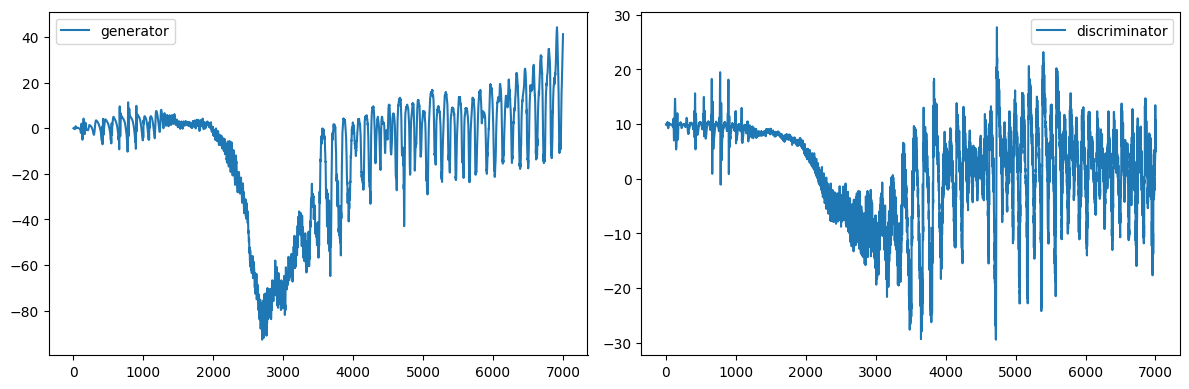

In [39]:
G_L = np.asarray(list_G)
D_L = np.asarray(list_D)
plt.figure(figsize=(12,4))
plt.subplot(1, 2, 1)
plt.plot(G_L, label='generator')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(D_L, label = 'discriminator')
plt.legend()
plt.tight_layout()

# Save the figure
plt.savefig('complex_pilots_gan_losses.png', dpi=300, bbox_inches='tight')

## Joint training

In [43]:
with open('gan_weights/complex_pilots_gan_weights_G_4000.pkl', 'rb') as f:
    g_weights = pickle.load(f)
WG.set_weights(g_weights)
with open('gan_weights/complex_pilots_gan_weights_D_4000.pkl', 'rb') as f:
    d_weights = pickle.load(f)
WD.set_weights(d_weights)

  0%|          | 0/30001 [00:00<?, ?it/s]

Epoch [0/3000] w_d:2.3866 gp: 0.0453, grad_norm: 1.0291 Loss_D: 2.4319 Loss_G: 0.4466, mse: 416618.5625
(0.027686357-0.08157153j) (-0.0016741378-0.0015005004j)


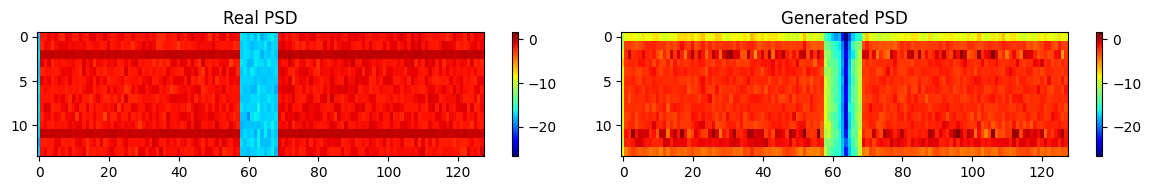

Iteration 0/30000, Eb/No: 9.9684, Loss_tx: 0.4581, Loss_rx: 0.4468
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.9960e-01 | 1.0000e+00 |      267051 |      534528 |          128 |         128 |         0.4 |reached target block errors
Epoch [250/3000] w_d:9.2619 gp: 0.0581, grad_norm: 1.0410 Loss_D: 9.3201 Loss_G: 2.1608, mse: 513068.2188
Epoch [500/3000] w_d:-3.0406 gp: 0.2285, grad_norm: 0.8677 Loss_D: -2.8121 Loss_G: 8.8029, mse: 394407.9688
(-0.0047796695+0.0019504678j) (-0.00075547025-0.0018101315j)


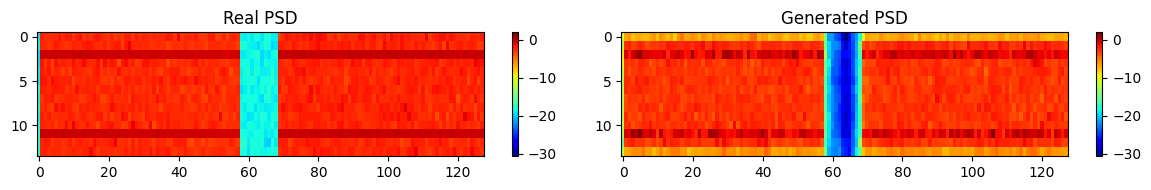

Iteration 5000/30000, Eb/No: 11.3170, Loss_tx: 0.3362, Loss_rx: -0.7334
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 7.4964e-04 | 6.8531e-03 |       22840 |    30468096 |           50 |        7296 |        21.8 |reached target block errors
Epoch [750/3000] w_d:4.4929 gp: 0.4291, grad_norm: 0.8179 Loss_D: 4.9220 Loss_G: 12.9901, mse: 410454.6250
Epoch [1000/3000] w_d:-5.9276 gp: 0.5783, grad_norm: 0.8047 Loss_D: -5.3493 Loss_G: 4.1401, mse: 423166.5000
(-0.05018599+0.039091587j) (-0.00073003833-0.0008442673j)


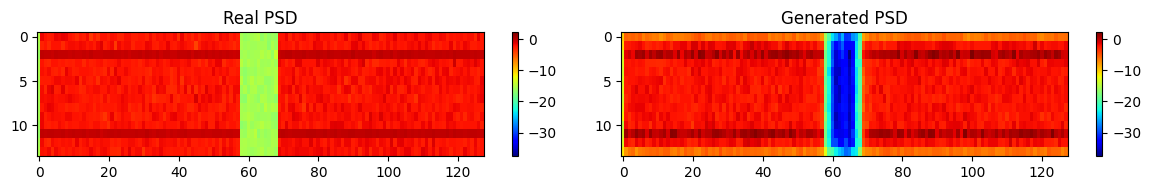

Iteration 10000/30000, Eb/No: 8.4926, Loss_tx: 0.3699, Loss_rx: -0.6139
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.6880e-03 | 1.2601e-02 |       27970 |    16570368 |           50 |        3968 |        12.7 |reached target block errors
Epoch [1250/3000] w_d:-1.7785 gp: 0.9168, grad_norm: 0.7226 Loss_D: -0.8617 Loss_G: 1.5128, mse: 520986.5312
Epoch [1500/3000] w_d:3.8466 gp: 1.4881, grad_norm: 0.6338 Loss_D: 5.3346 Loss_G: 12.3258, mse: 411583.0625
(-0.0639062+0.012333707j) (0.00043736544-0.00041860837j)


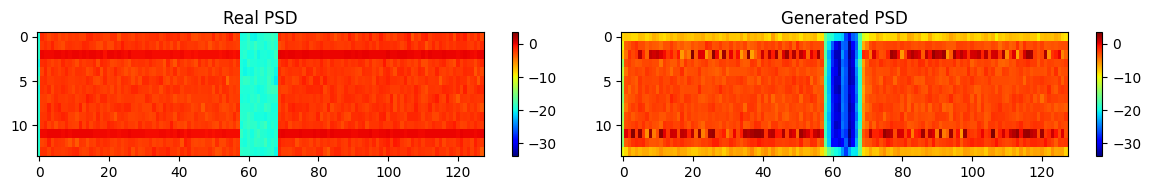

Iteration 15000/30000, Eb/No: 11.9556, Loss_tx: 1.0012, Loss_rx: -0.6911
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.3128e-03 | 1.0557e-02 |       25963 |    19777536 |           50 |        4736 |        14.3 |reached target block errors
Epoch [1750/3000] w_d:7.2067 gp: 1.1988, grad_norm: 0.6819 Loss_D: 8.4055 Loss_G: 16.6545, mse: 430901.6250
Epoch [2000/3000] w_d:7.7277 gp: 0.7160, grad_norm: 0.7599 Loss_D: 8.4437 Loss_G: 14.6721, mse: 466460.7500
(-0.08699809+0.0013830172j) (0.0014455365+0.0011688916j)


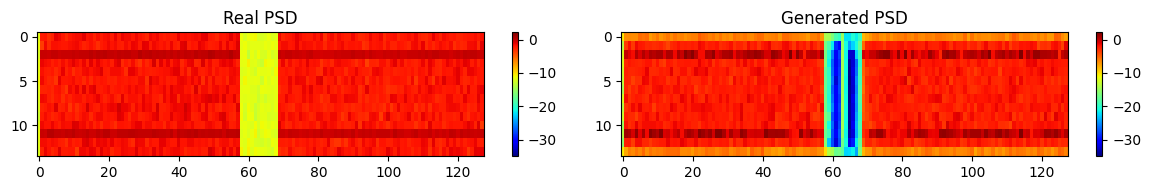

Iteration 20000/30000, Eb/No: 4.4616, Loss_tx: 0.3831, Loss_rx: -0.4574
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.5457e-03 | 1.2601e-02 |       25612 |    16570368 |           50 |        3968 |        13.2 |reached target block errors
Epoch [2250/3000] w_d:4.2473 gp: 0.2300, grad_norm: 1.0334 Loss_D: 4.4772 Loss_G: -10.3703, mse: 520187.3125
Epoch [2500/3000] w_d:7.1348 gp: 0.4697, grad_norm: 1.1627 Loss_D: 7.6045 Loss_G: 24.6253, mse: 428791.0625
(-0.010865937-0.018858457j) (-0.0011871086+7.417601e-05j)


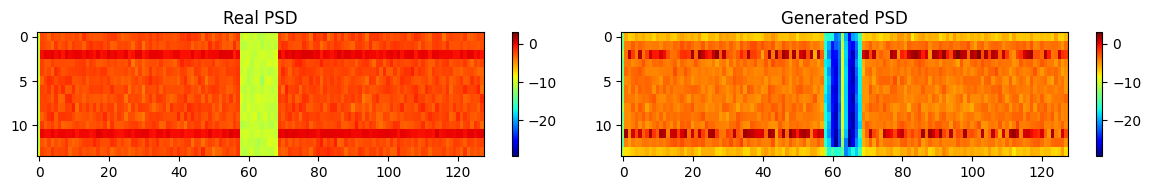

Iteration 25000/30000, Eb/No: 2.9612, Loss_tx: 0.3943, Loss_rx: -0.3811
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.5620e-03 | 1.0769e-02 |       30893 |    19777536 |           51 |        4736 |        14.4 |reached target block errors
Epoch [2750/3000] w_d:6.0207 gp: 0.1169, grad_norm: 0.9573 Loss_D: 6.1376 Loss_G: 49.4884, mse: 450787.1250
Epoch [3000/3000] w_d:4.7873 gp: 0.7173, grad_norm: 0.7416 Loss_D: 5.5046 Loss_G: 49.1929, mse: 388825.6875
(-0.116038896-0.012798026j) (0.0004148262+0.0016925392j)


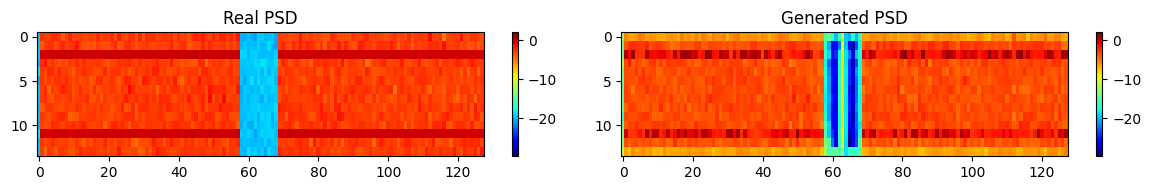

Iteration 30000/30000, Eb/No: 12.2066, Loss_tx: -0.1765, Loss_rx: -0.7720
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 1.0634e-03 | 8.6806e-03 |       25579 |    24053760 |           50 |        5760 |        17.3 |reached target block errors


In [44]:
offset = 0
grad_check = 1
for i in tqdm(range(offset, num_training_iterations+1)):
    
    train_GAN = True if (i % 10 == 0) else False # Train GAN every 10 iterations (30000/10=3000 times)

    # Sampling a batch of SNRs
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    if train_GAN:
        _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    
        # condition
        condition = pilots # y_real, h_hat_lmmse, pilots
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
        
        gan_weights_G = WG.get_weights()
        gan_weights_D = WD.get_weights()
    
        # -----------------------------------------------------------------------     
        list_D.append(loss_D)
        list_G.append(loss_G)
        if i % 2500 == 0: 
            psd_real = compute_psd(y_real) # psd averaged over batch and 14 ofdm -> fft psd 
            psd_generated = compute_psd(y_fake)
            mse= tf.reduce_sum(tf.abs(y_real - y_fake)**2)
    
            print(f"Epoch [{i//10}/{num_training_iterations//10}] w_d:{loss_D.numpy()-gp.numpy():.4f} gp: {gp.numpy():.4f}, grad_norm: {grad_norm.numpy():.4f} Loss_D: {loss_D.numpy():.4f} Loss_G: {loss_G.numpy():.4f}, mse: {mse.numpy():.4f}") 
    
        if i % 5000 == 0: 
            print(np.mean(y_fake), np.mean(y_real))
            
            # psd_real_line = compute_psd_line(y_real)
            # psd_generated_line = compute_psd_line(y_fake)
            # plot_psd_line(psd_real_line, psd_generated_line)
            
            # plot_phase_amp_distribution(y_real, y_fake)
    
            plot_psd(psd_real, psd_generated)
    
        if i % 5000 == 0: 
            # save GAN weights
            with open(f'gan_weights/e2e_complex_pilots_gan_weights_G_{i}.pkl', 'wb') as f2:
                pickle.dump(gan_weights_G, f2)
            with open(f'gan_weights/e2e_complex_pilots_gan_weights_D_{i}.pkl', 'wb') as f3:
                    pickle.dump(gan_weights_D, f3)

            # np.savez('e2e_receivedY_gan_losses.npz', generator=np.asarray(list_G), discriminator=np.asarray(list_D))

    # -----------------------------------------------------------------------
    gan_weights_G = WG.get_weights()
    model._gan_channel.set_weights(gan_weights_G)
    # -----------------------------------------------------------------------
    
    # ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    loss_tx, y_gen, y_real, grads_tx = E2E_train__tx_step(ebno_db)
    
    # if grad_check == 1:
    #     print("=" * 10 + "Grads_tx" + "=" * 10)
    #     for i, (grad_tx, weight_tx) in enumerate(zip(grads_tx, model.trainable_weights)):
    #         if grad_tx is None:
    #             print(f"❌ None    : {weight_tx.name} - Shape: {weight_tx.shape}")
    #         else:
    #             print(f"✅ Valid   : {weight_tx.name} - Shape: {weight_tx.shape}")

    loss_rx, grads_rx = E2E_train__rx_step(ebno_db)

    # if grad_check == 1:
    #     print("=" * 10 + "Grads_rx" + "=" * 10)
    #     for j, (grad_rx, weight_rx) in enumerate(zip(grads_rx, model.trainable_weights)):
    #         if grad_rx is None:
    #             print(f"❌ None    : {weight_rx.name} - Shape: {weight_rx.shape}")
    #         else:
    #             print(f"✅ Valid   : {weight_rx.name} - Shape: {weight_rx.shape}")
    # grad_check += 1
     
    for layer in model.layers:
        layer.trainable = True
    weights = model.get_weights()
        
    if i % 5000 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss_tx: {loss_tx.numpy():.4f}, Loss_rx: {loss_rx.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        # validation at 3.5dB
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/complex_pilots_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)
        tf.keras.backend.clear_session()

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/complex_pilots_neural_receiver_weights_trained.pkl', 'wb') as f:
    pickle.dump(weights, f)


### Joint training (baseline)

In [46]:
offset = 0
grad_check = 0
model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=False)
# with open('weights_trained/baseline_model_weights_35000.pkl', 'rb') as f:
#     weights = pickle.load(f)
# model.set_weights(weights)

for i in tqdm(range(offset, num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    weights = model.trainable_weights
    # for w in weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db, use_gan_channel=False)
        loss = -rate 
    
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))
     
    if i % 2500 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32), use_gan_channel=False)
        eval_model.set_weights(weights)
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 10000 == 0:
        with open(f'weights_trained/qam_baseline_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/baseline_weights_QAMmapper.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 9.9684, Loss: 0.5893
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     20.0 | 5.0055e-01 | 1.0000e+00 |      267559 |      534528 |          128 |         128 |         0.6 |reached target block errors
Iteration 2500/30000, Eb/No: 7.2272, Loss: -0.5778
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     20.0 | 2.8184e-05 | 3.9063e-04 |        3013 |   106905600 |           10 |       25600 |        78.3 |reached max iterations
Iteration 5000/30000, Eb/No: 11.3170, Loss: -0.7496
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block e

### Joint training (Hybrid)

In [59]:
offset = 0
model(batch_size, tf.constant(10.0, tf.float32))
# with open('weights_trained/baseline_model_weights_35000.pkl', 'rb') as f:
#     weights = pickle.load(f)
# model.set_weights(weights)

for i in tqdm(range(offset, num_training_iterations+1)):
    ebno_db = tf.random.uniform(shape=[], minval=ebno_db_min, maxval=ebno_db_max)
    
    weights = model.trainable_weights
    # for w in weights:
    #     print(f"Layer: {w.name}, Shape: {w.shape}")
    
    with tf.GradientTape() as tape:
        rate = model(batch_size, ebno_db)
        loss = -rate 
    
    grads = tape.gradient(loss, weights)
    optimizer.apply_gradients(zip(grads, weights))
     
    if i % 2500 == 0:
        log_str = f"Iteration {i}/{num_training_iterations}, Eb/No: {ebno_db.numpy():.4f}, Loss: {loss.numpy():.4f}"
        print(log_str)
        
        eval_model(1, tf.constant(10.0, tf.float32))
        eval_model.set_weights(weights)
        ber, bler = sim_ber(eval_model, [10.0], batch_size=128, num_target_block_errors=50, max_mc_iter=200) 

    if i % 5000 == 0:
        with open(f'weights_trained/LS_MMSEqualization_model_weights_{i}.pkl', 'wb') as f:
            pickle.dump(weights, f)

# Save the weights in a file
weights = model.get_weights()
with open('eval_weights/LS_MMSEqualization_weights_NNdemapper.pkl', 'wb') as f:
    pickle.dump(weights, f)

  0%|          | 0/30001 [00:00<?, ?it/s]

Iteration 0/30000, Eb/No: 9.9684, Loss: 0.0041
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 4.7747e-01 | 1.0000e+00 |      255220 |      534528 |          128 |         128 |         0.5 |reached target block errors
Iteration 2500/30000, Eb/No: 7.2272, Loss: -0.5206
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
     10.0 | 3.0061e-03 | 2.6562e-02 |       24103 |     8017920 |           51 |        1920 |         4.4 |reached target block errors
Iteration 5000/30000, Eb/No: 11.3170, Loss: -0.7088
EbNo [dB] |        BER |       BLER |  bit errors |    num bits | bl

### Learned Constellation <a class="anchor" id="Constellation"></a>

In [ ]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem(training=True, use_fec=True)
load_weights(model, "eval_weights/complex_pilots_neural_receiver_weights_trained.pkl")

constellation = model.constellation

# Extract the actual constellation points as numpy array
# The constellation points are constructed from the trainable variables
constellation_points = tf.complex(model.points_r, model.points_i).numpy()

figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05

fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained mapper")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")

for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )

plt.show()

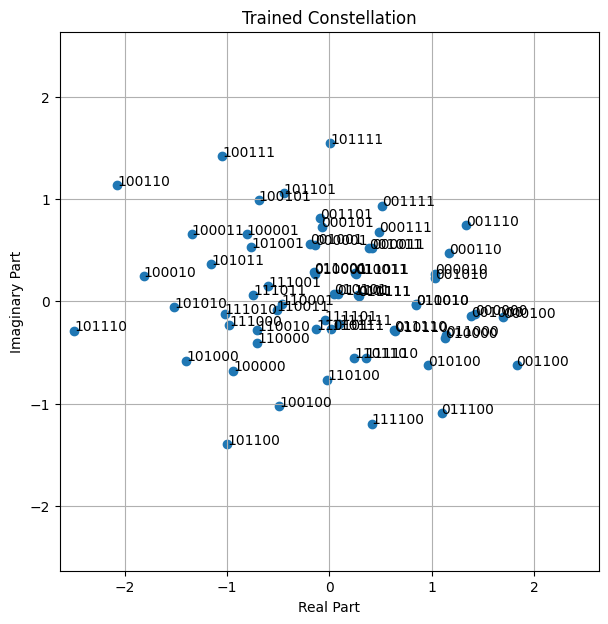

In [58]:
def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)
    
# Load the model and weights
model = E2ESystem(training=True, use_fec=True)
load_weights(model, "eval_weights/complex_pilots_neural_receiver_weights_trained.pkl")

# Extract constellation points from the stacked representation
constellation_points = tf.complex(model.constellation_points[0], 
                                  model.constellation_points[1]).numpy()

figsize = (7, 7)
maxval = np.max(np.abs(constellation_points)) * 1.05
fig = plt.figure(figsize=figsize)
ax = fig.add_subplot(111)
plt.xlim(-maxval, maxval)
plt.ylim(-maxval, maxval)
plt.scatter(np.real(constellation_points), np.imag(constellation_points))
ax.set_aspect("equal", adjustable="box")
plt.grid(True, which="both", axis="both")
plt.title("Trained Constellation")
plt.xlabel("Real Part")
plt.ylabel("Imaginary Part")
for j, p in enumerate(constellation_points):
    plt.annotate(
        np.binary_repr(j, num_bits_per_symbol),
        (np.real(p), np.imag(p))
    )
plt.show()

In [ ]:
# current_config = {
#     'weight_path': 'weights_trained/pilots_model_weights_50000.pkl',
#     'condition_label': r'$\mathbf{x}_p$ and $\mathbf{y}_p$', 
#     'subplot_index': 0,  # 0, 1, or 2
#     'subplot_label': '(a)'  # '(a)', '(b)', or '(c)'
# }

# current_config = {
#     'weight_path': 'weights_trained/hhat_model_weights_50000.pkl',
#     'condition_label': r'$\hat{\mathbf{h}}$', 
#     'subplot_index': 1,
#     'subplot_label': '(b)'
# }

current_config = {
    'weight_path': 'weights_trained/receivedY_model_weights_50000.pkl',
    'condition_label': r'$\mathbf{Y}_{rg}$', 
    'subplot_index': 2,
    'subplot_label': '(c)'
}

# File to store the figure state
data_state_file = 'constellation_data_state.pkl'

def extract_constellation_data(weight_path):
    """Extract constellation data without plotting"""
    model = E2ESystem(training=True, use_fec=True)
    load_weights(model, weight_path)
    constellation = model.constellation
    return constellation.points

# Load existing data or create new storage
if os.path.exists(data_state_file):
    with open(data_state_file, 'rb') as f:
        plot_data = pickle.load(f)
    print(f"Loaded existing data. Completed: {list(plot_data.keys())}")
else:
    plot_data = {}
    print("Created new data storage")

# Extract and store constellation data for current config
subplot_idx = current_config['subplot_index']
if subplot_idx not in plot_data:
    print(f"Extracting data for subplot {subplot_idx}: {current_config['condition_label']}")
    
    constellation_points = extract_constellation_data(current_config['weight_path'])
    
    plot_data[subplot_idx] = {
        'points': constellation_points,
        'condition_label': current_config['condition_label'],
        'subplot_label': current_config['subplot_label']
    }
    
    # Save the data
    with open(data_state_file, 'wb') as f:
        pickle.dump(plot_data, f)
        
    print(f"Saved data for subplot {subplot_idx}")
else:
    print(f"Data for subplot {subplot_idx} already exists")

print(f"Progress: {len(plot_data)}/3 subplots completed")

# Create and save the complete figure when all data is ready
if len(plot_data) == 3:
    print("All data ready! Creating final plot...")
    
    # Set IEEE paper style
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'font.family': 'serif',
        'font.serif': 'Times New Roman'
    })
    
    # Create fresh figure
    fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.5))
    
    # Plot all subplots
    for i in range(3):
        data = plot_data[i]
        points = data['points']
        condition_label = data['condition_label']
        subplot_label = data['subplot_label']
        
        maxval = np.max(np.abs(points)) * 1.05
        axes[i].set_xlim(-maxval, maxval)
        axes[i].set_ylim(-maxval, maxval)
        axes[i].scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        axes[i].set_aspect("equal", adjustable="box")
        axes[i].grid(True, which="both", axis="both", alpha=0.3)
        axes[i].set_title(f"{subplot_label} {condition_label}")
        axes[i].set_xlabel("Real Part")
        axes[i].set_ylabel("Imaginary Part")
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.4)
    
    # Save EPS
    plt.savefig('learned_constellations.eps', format='eps', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Saved learned_constellations.eps successfully!")
    
    # Clean up
    if os.path.exists(data_state_file):
        os.remove(data_state_file)
        print("Cleaned up data file")

else:
    # Show preview of current data
    if plot_data:
        plt.figure(figsize=(3, 3))
        latest_data = plot_data[max(plot_data.keys())]
        points = latest_data['points']
        maxval = np.max(np.abs(points)) * 1.05
        plt.xlim(-maxval, maxval)
        plt.ylim(-maxval, maxval)
        plt.scatter(np.real(points), np.imag(points), s=30, alpha=0.7)
        plt.title(f"Preview: {latest_data['condition_label']}")
        plt.grid(True, alpha=0.3)
        plt.show()

## Evaluation of the Neural Receiver <a class="anchor" id="Evaluation-of-the-Neural-Receiver"></a>

In [ ]:
ebno_dbs_eval = np.arange(0.0, # Min SNR for evaluation
                     30.0, # Max SNR for evaluation
                     1.0) # Step

In [35]:
# conventional system
conv_model = E2EConvSystem('baseline-perfect-csi', False, True)
ber,bler  = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=100)
BER['baseline-perfect-csi'] = ber.numpy()
BLER['baseline-perfect-csi'] = bler.numpy()

conv_model = E2EConvSystem('baseline-ls-estimation', False, True)
ber,bler  = sim_ber(conv_model, ebno_dbs, batch_size=128, num_target_block_errors=100, max_mc_iter=100)
BER['baseline-ls-estimation'] = ber.numpy()
BLER['baseline-ls-estimation'] = bler.numpy()

with open('eval_result/coderate12_SISO_baseline_e3000', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8482e-01 | 1.0000e+00 |      152245 |      534528 |          128 |         128 |         8.0 |reached target block errors
      0.5 | 2.7331e-01 | 1.0000e+00 |      146091 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.0 | 2.6334e-01 | 1.0000e+00 |      140760 |      534528 |          128 |         128 |         0.3 |reached target block errors
      1.5 | 2.5003e-01 | 1.0000e+00 |      133646 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.0 | 2.3991e-01 | 1.0000e+00 |      128239 |      534528 |          128 |         128 |         0.3 |reached target block errors
      2.5 | 2.2625e-01 | 1.0000e+00 |      120939 |      534528 |

In [ ]:
# with open('eval_result/baseline_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER = BER
# BLER = BLER

with open('eval_weights/baseline_weights_QAMmapper.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-standard'] = bler.numpy()
BER['neural-receiver-standard'] = ber.numpy()

with open('eval_result/baseline_model_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.9080e-01 | 1.0000e+00 |      155443 |      534528 |          128 |         128 |         0.5 |reached target block errors
      0.5 | 2.8105e-01 | 1.0000e+00 |      150231 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.6889e-01 | 1.0000e+00 |      143729 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.5806e-01 | 1.0000e+00 |      137939 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.4833e-01 | 1.0000e+00 |      132739 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.3460e-01 | 1.0000e+00 |      125398 |      534528 |

In [38]:
# with open('eval_result/baseline_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER = BER
# BLER = BLER

with open('eval_weights/baseline_weights_NNmapper.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-trained'] = bler.numpy()
BER['neural-receiver-trained'] = ber.numpy()

with open('eval_result/baseline_model_result', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.8337e-01 | 1.0000e+00 |      151467 |      534528 |          128 |         128 |         0.4 |reached target block errors
      0.5 | 2.7256e-01 | 1.0000e+00 |      145690 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.6173e-01 | 1.0000e+00 |      139903 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.4932e-01 | 1.0000e+00 |      133267 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.3827e-01 | 1.0000e+00 |      127361 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.2417e-01 | 1.0000e+00 |      119825 |      534528 |

In [45]:
with open('eval_weights/complex_pilots_neural_receiver_weights_trained.pkl', 'rb') as f:
    weights = pickle.load(f)
eval_model(1, tf.constant(10.0, tf.float32))
eval_model.set_weights(weights)

# Evaluations
ber,bler = sim_ber(eval_model, ebno_dbs, batch_size=128, num_target_block_errors=50, max_mc_iter=3000)
BLER['neural-receiver-trained'] = bler.numpy()
BER['neural-receiver-trained'] = ber.numpy()

with open('eval_result/complex_pilots_neural_receiver_results', 'wb') as f:
    pickle.dump((ebno_dbs, BLER, BER), f)

EbNo [dB] |        BER |       BLER |  bit errors |    num bits | block errors |  num blocks | runtime [s] |    status
---------------------------------------------------------------------------------------------------------------------------------------
      0.0 | 2.9169e-01 | 1.0000e+00 |      155914 |      534528 |          128 |         128 |         0.6 |reached target block errors
      0.5 | 2.8355e-01 | 1.0000e+00 |      151566 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.0 | 2.7437e-01 | 1.0000e+00 |      146658 |      534528 |          128 |         128 |         0.4 |reached target block errors
      1.5 | 2.6579e-01 | 1.0000e+00 |      142072 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.0 | 2.5383e-01 | 1.0000e+00 |      135678 |      534528 |          128 |         128 |         0.4 |reached target block errors
      2.5 | 2.4446e-01 | 1.0000e+00 |      130669 |      534528 |

## Plot

Finally, we plots the BLERs

/tmp/ipykernel_2572726/3894608922.py:55: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim((1e-3, 0))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


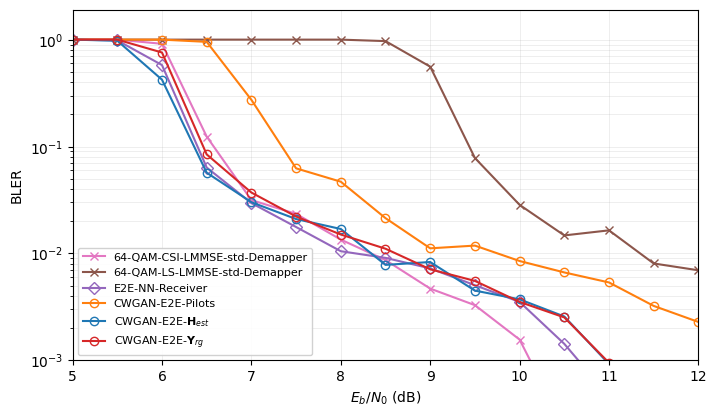

In [62]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['legend.fontsize'] = 8

fig = plt.figure(figsize=(7, 4))

with open('eval_result/coderate12_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_base = BER
BLER_base = BLER
# both QAM+deeprx and NNmapper+deeprx
with open('eval_result/baseline_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_st = BER
BLER_st = BLER
with open('eval_result/receivedY_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_g = BER
BLER_g = BLER
with open('eval_result/hhat_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_hh = BER
BLER_hh = BLER
with open('eval_result/pilots_neural_receiver_results', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_pp = BER
BLER_pp = BLER
# with open('eval_result/MMSEequalization_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_mmse = BER
# BLER_mmse = BLER
with open('eval_result/LS_MMSEequalization_model_result', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_ls_mmse = BER
BLER_ls_mmse = BLER
# with open('eval_result/LS_NNequalization_model_result', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_nn_eq = BER
# BLER_nn_eq = BLER

plt.semilogy(ebno_dbs, BLER_base['baseline-perfect-csi'], 'x-', c=f'C6', label=f'64-QAM-CSI-LMMSE-std-Demapper')
plt.semilogy(ebno_dbs, BLER_base['baseline-ls-estimation'], 'x-', c=f'C5', label=f'64-QAM-LS-LMMSE-std-Demapper')
# plt.semilogy(ebno_dbs, BLER_st['neural-receiver-standard'], 'x-', c=f'C9', label=f'64-QAM-NN-Receiver')
# plt.semilogy(ebno_dbs, BLER_mmse['neural-receiver-trained'], 'D-', c=f'C8', markerfacecolor='none', label=f'E2E-NN-Mapper-CSI-LMMSE-NN-Demapper')
# plt.semilogy(ebno_dbs, BLER_ls_mmse['neural-receiver-trained'], 'D-', c=f'C2', markerfacecolor='none', label=f'E2E-LS-LMMSE-NN-Demapper')
# plt.semilogy(ebno_dbs, BLER_nn_eq['neural-receiver-trained'], 'D-', c=f'C7', markerfacecolor='none', label=f'E2E-NN-Mapper-LS-NN-Equalizer-Demapper')
plt.semilogy(ebno_dbs, BLER_st['neural-receiver-trained'], 'D-', c=f'C4', markerfacecolor='none', label=f'E2E-NN-Receiver')
plt.semilogy(ebno_dbs, BLER_pp['neural-receiver-trained'], 'o-', c=f'C1', markerfacecolor='none', label=r'CWGAN-E2E-Pilots')
plt.semilogy(ebno_dbs, BLER_hh['neural-receiver-trained'], 'o-', c=f'C0', markerfacecolor='none', label=r'CWGAN-E2E-$\mathbf{H}_{est}$')
plt.semilogy(ebno_dbs, BLER_g['neural-receiver-trained'], 'o-', c=f'C3', markerfacecolor='none', label=r'CWGAN-E2E-$\mathbf{Y}_{rg}$')

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BLER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
plt.ylim((1e-3, 0))
plt.xlim((5, 12))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)

plt.tight_layout(pad=0.1)
plt.savefig('plots/bler.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/bler.eps', format='eps', bbox_inches='tight')
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


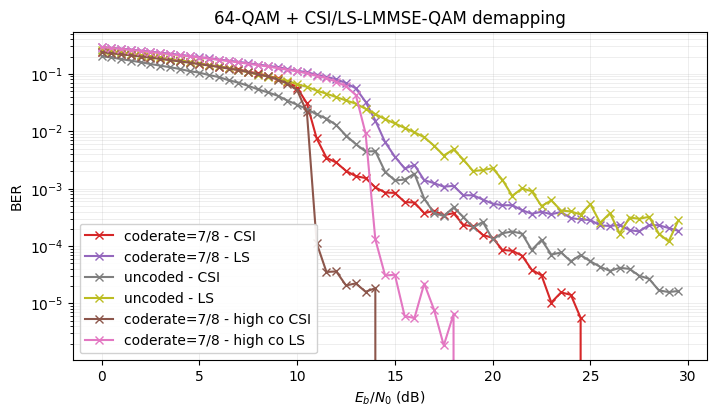

In [54]:
fig = plt.figure(figsize=(7, 4))

with open('eval_result/coderate78_highCo_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_highco78_code = BER
BLER_highco78_code = BLER

# with open('eval_result/coderate12_SISO_baseline_e3000', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_base12_code = BER
# BLER_base12_code = BLER
# with open('eval_result/coderate34_SISO_baseline_e3000', 'rb') as file: 
#         ebno_dbs, BLER, BER = pickle.load(file)
# BER_base34_code = BER
# BLER_base34_code = BLER
with open('eval_result/coderate78_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs, BLER, BER = pickle.load(file)
BER_base78_code = BER
BLER_base78_code = BLER
with open('eval_result/uncoded_SISO_baseline_e3000', 'rb') as file: 
        ebno_dbs2, BLER, BER = pickle.load(file)
BER_uncoded_code = BER
BLER_uncoded_code = BLER

# plt.semilogy(ebno_dbs, BER_base12_code['baseline-perfect-csi'], 'x-', c=f'C6', label=f'coderate=1/2 - 64-QAM + CSI-LMMSE-QAM demapping')
# plt.semilogy(ebno_dbs, BER_base12_code['baseline-ls-estimation'], 'x-', c=f'C5', label=f'coderate=1/2 - 64-QAM-LS-LMMSE-std-Demapper')
# plt.semilogy(ebno_dbs, BER_base34_code['baseline-perfect-csi'], 'x-', c=f'C1', label=f'coderate=3/4 - 64-QAM + CSI-LMMSE-QAM demapping')
# plt.semilogy(ebno_dbs, BER_base34_code['baseline-ls-estimation'], 'x-', c=f'C2', label=f'coderate=3/4 - 64-QAM-LS-LMMSE-std-Demapper')
plt.semilogy(ebno_dbs, BER_base78_code['baseline-perfect-csi'], 'x-', c=f'C3', label=f'coderate=7/8 - CSI')
plt.semilogy(ebno_dbs, BER_base78_code['baseline-ls-estimation'], 'x-', c=f'C4', label=f'coderate=7/8 - LS')

plt.semilogy(ebno_dbs2, BER_uncoded_code['baseline-perfect-csi'], 'x-', c=f'C7', label=f'uncoded - CSI')
plt.semilogy(ebno_dbs2, BER_uncoded_code['baseline-ls-estimation'], 'x-', c=f'C8', label=f'uncoded - LS')

plt.semilogy(ebno_dbs, BER_highco78_code['baseline-perfect-csi'], 'x-', c=f'C5', label=f'coderate=7/8 - high co CSI')
plt.semilogy(ebno_dbs, BER_highco78_code['baseline-ls-estimation'], 'x-', c=f'C6', label=f'coderate=7/8 - high co LS')

plt.xlabel(r"$E_b/N_0$ (dB)", fontsize=10)
plt.ylabel("BER", fontsize=10)
plt.grid(which="both", linewidth=0.5, alpha=0.3)
# plt.ylim((1e-2, 0))
# plt.xlim((5, 12))

plt.legend(loc='lower left', frameon=True, framealpha=0.9, 
           ncol=1, handlelength=2, columnspacing=1)
plt.title('64-QAM + CSI/LS-LMMSE-QAM demapping')
plt.tight_layout(pad=0.1)
plt.savefig('plots/coderate78_ber.png', format='png', dpi=300, bbox_inches='tight')
plt.savefig('plots/coderate78_ber.eps', format='eps', bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import gaussian_kde

model = E2ESystem(training=True, use_fec=True)
eval_model = E2ESystem(training=False, use_fec=True)

model(1, tf.constant(10.0, tf.float32))
with open(model_weights_path_trained, 'rb') as f:
    weights = pickle.load(f)
model.set_weights(weights)

eval_model(1, tf.constant(10.0, tf.float32))
names = [w.name for w in model.trainable_weights]
eval_weights = [weight for name, weight in zip(names, weights) if "gan_channel" not in name]
eval_model.set_weights(eval_weights)

model.summary()
eval_model.summary()

nn_para = np.zeros(1)
for layer in model.layers:
    for weight in layer.weights:
        nn_para = np.concatenate((nn_para, weight.numpy().reshape(-1)), axis=0)

# Gaussian kernel density estimate
data = nn_para  # Replace with your data
kde = gaussian_kde(data[0:1000])

x = np.linspace(min(data), max(data), 1000)

plt.figure(figsize=(8, 6))
plt.plot(x, kde(x), label='PDF')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.title('Probability Density Function')
plt.legend()
plt.grid(True)
plt.show()

## Other

### distribution

In [ ]:
def test_trained_gan_100_realizations(model, WG, WD, epoch_to_load=1000):
    # Load trained weights
    with open(f'gan_weights/e2e_receivedY_gan_weights_G_{epoch_to_load}.pkl', 'rb') as f:
        gan_weights_G = pickle.load(f)
    with open(f'gan_weights/e2e_receivedY_gan_weights_D_{epoch_to_load}.pkl', 'rb') as f:
        gan_weights_D = pickle.load(f)
    
    WG.set_weights(gan_weights_G)
    WD.set_weights(gan_weights_D)
    
    real_freq_responses = []
    fake_freq_responses = []
    real_amplitudes_all = []
    fake_amplitudes_all = []
    real_phases_all = []
    fake_phases_all = []
    
    batch_size = 128
    ebno_db = tf.constant(5.0, tf.float32)  # Fixed SNR
    
    # 100 realizations = 100*14*128 =179200 ofdm symbols
    _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    for i in tqdm(range(100)):
        # _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
        
        d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, y_real) # change the condition
        
        # average each realization over batch and OFDM symbols: [batch,ant,ant,14,128] -> [128]
        real_avg = tf.reduce_mean(y_real, axis=[0, 1, 2, 3]).numpy()  # [128]
        fake_avg = tf.reduce_mean(y_fake, axis=[0, 1, 2, 3]).numpy()  # [128]
        
        # frequency responses
        real_freq_responses.append(real_avg)
        fake_freq_responses.append(fake_avg)
        # amplitudes and phases for PDF analysis
        real_amps = np.abs(y_real.numpy()).flatten()
        fake_amps = np.abs(y_fake.numpy()).flatten()
        real_phases = np.angle(y_real.numpy()).flatten()
        fake_phases = np.angle(y_fake.numpy()).flatten()
        
        real_amplitudes_all.extend(real_amps)
        fake_amplitudes_all.extend(fake_amps)
        real_phases_all.extend(real_phases)
        fake_phases_all.extend(fake_phases)
    
    # compute averages
    real_freq_responses = np.array(real_freq_responses)  # [100, 128]
    fake_freq_responses = np.array(fake_freq_responses)  # [100, 128]
    final_real_avg = np.mean(real_freq_responses, axis=0)  # [128]
    final_fake_avg = np.mean(fake_freq_responses, axis=0)  # [128]
    real_amplitudes_all = np.array(real_amplitudes_all)
    fake_amplitudes_all = np.array(fake_amplitudes_all)
    real_phases_all = np.array(real_phases_all)
    fake_phases_all = np.array(fake_phases_all)
    
    # ===== PLOT 1: average mag/phase =====
    freq_axis = np.linspace(-0.5, 0.5, len(final_real_avg))
    
    plt.figure(figsize=(8, 6))
    
    # magnitude plot
    plt.subplot(2, 1, 1)
    plt.plot(freq_axis, 20*np.log10(np.abs(final_real_avg)), 'b-', label='Real Channel', linewidth=1)
    plt.plot(freq_axis, 20*np.log10(np.abs(final_fake_avg)), 'ro--', markerfacecolor='none', label='GAN Channel', linewidth=1)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Magnitude [dB]')
    plt.legend()
    plt.grid(True)
    # phase plot
    plt.subplot(2, 1, 2)
    plt.plot(freq_axis, np.angle(final_real_avg), 'b-', label='Real Channel', linewidth=1)
    plt.plot(freq_axis, np.angle(final_fake_avg), 'ro--', markerfacecolor='none', label='GAN Channel', linewidth=1)
    plt.xlabel('Normalized Frequency')
    plt.ylabel('Phase [rad]')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    # plt.savefig('averaged_frequency_response_100_realizations.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ===== PLOT 2: channel response amplitude distribution =====
    plt.figure(figsize=(6, 4))
    max_amp = max(np.max(real_amplitudes_all), np.max(fake_amplitudes_all))
    bins = np.linspace(0, max_amp, 80)

    plt.hist(real_amplitudes_all, bins=bins, alpha=0.7, density=True, 
             label='Real Samples', color='blue', histtype='step', linewidth=1)
    plt.hist(fake_amplitudes_all, bins=bins, alpha=0.7, density=True, 
             label='Generated Samples', color='red', histtype='step', linewidth=1, linestyle='--')
    
    plt.xlabel('channel response')
    plt.ylabel('Probability Density Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, max_amp)

    plt.tight_layout()
    # plt.savefig('channel_amplitude_distribution.png', dpi=300, bbox_inches='tight')

    plt.figure(figsize=(6, 4))
    max_phase = max(np.max(real_phases_all), np.max(fake_phases_all))
    bins = np.linspace(0, max_phase, 80)

    plt.hist(real_phases_all, bins=bins, alpha=0.7, density=True, 
             label='Real Samples', color='blue', histtype='step', linewidth=1)
    plt.hist(fake_phases_all, bins=bins, alpha=0.7, density=True, 
             label='Generated Samples', color='red', histtype='step', linewidth=1, linestyle='--')
    
    plt.xlabel('channel response')
    plt.ylabel('Probability Density Function')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, max_phase)
    
    plt.tight_layout()
    # plt.savefig('channel_phase_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
model = E2ESystem(training=True, use_fec=True)

WG = GANGenerator()
WD = GANDiscriminator()

test_trained_gan_100_realizations(model, WG, WD, 30000)

In [ ]:
# amplitude distribution
real_amplitudes_all = []
fake_amplitudes_all = []
batch_size = 128
ebno_db = tf.constant(10.0, tf.float32)

model = E2ESystem(training=True, use_fec=True)
WG = GANGenerator()
WD = GANDiscriminator()

def load_weights(model, model_weights_path, gan_weights_path):
    with open(f'gan_weights/e2e_{gan_weights_path}_gan_weights_G_30000.pkl', 'rb') as f:
        gan_weights_G = pickle.load(f)
    with open(f'gan_weights/e2e_{gan_weights_path}_gan_weights_D_30000.pkl', 'rb') as f:
        gan_weights_D = pickle.load(f)
    
    WG.set_weights(gan_weights_G)
    WD.set_weights(gan_weights_D)

    model(batch_size, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)

# load_weights(model, "weights_trained/pilots_model_weights_15000.pkl", "pilots")
load_weights(model, "weights_trained/hhat_model_weights_30000.pkl", "hhat")
# load_weights(model, "weights_trained/receivedY_model_weights_30000.pkl", "receivedY")

for i in tqdm(range(100)):  # 100 realizations
    # _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    _, x_rg, _, y_real, h_freq, h_hat, pilots, sigma2 = model(batch_size, ebno_db, use_gan_channel=True)
    
    # Get generated samples from GAN
    condition = h_hat
    d_real, d_fake, loss_D, loss_G, gp, grad_norm, y_fake = WGAN_train_step(y_real, x_rg, condition) 
    
    # Collect amplitudes
    real_amps = np.abs(y_real.numpy()).flatten()
    fake_amps = np.abs(y_fake.numpy()).flatten()
    
    real_amplitudes_all.extend(real_amps)
    fake_amplitudes_all.extend(fake_amps)

real_amplitudes_all = np.array(real_amplitudes_all)
fake_amplitudes_all = np.array(fake_amplitudes_all)

np.save("plots/cond_amplitudes_real_model_hhat.npy", real_amplitudes_all)
np.save("plots/cond_amplitudes_fake_model_hhat.npy", fake_amplitudes_all)
print(f"Saved {len(real_amplitudes_all)} real amplitude samples")
print(f"Saved {len(fake_amplitudes_all)} generated amplitude samples")

  0%|          | 0/100 [00:00<?, ?it/s]

Saved 22937600 real amplitude samples
Saved 22937600 generated amplitude samples


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


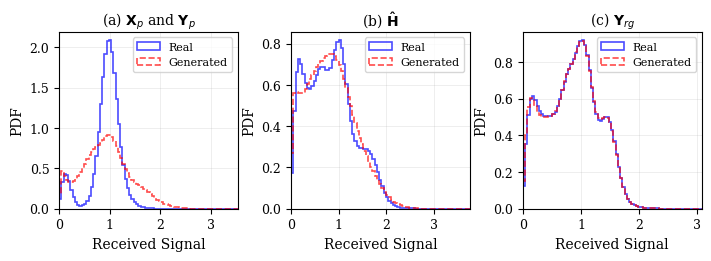

In [139]:
# IEEE formatting parameters
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.titlesize'] = 11

# Load data
amplitude_files_real = [
    "plots/cond_amplitudes_real_model_pilots.npy",
    "plots/cond_amplitudes_real_model_hhat.npy",
    "plots/cond_amplitudes_real_model_receivedY.npy"
]
amplitude_files_fake = [
    "plots/cond_amplitudes_fake_model_pilots.npy",
    "plots/cond_amplitudes_fake_model_hhat.npy",
    "plots/cond_amplitudes_fake_model_receivedY.npy"
]

titles = ["(a) $\mathbf{X}_p$ and $\mathbf{Y}_p$", "(b) $\mathbf{\hat H}$", "(c) $\mathbf{Y}_{rg}$"]

# IEEE double column width is ~7 inches, single column is ~3.5 inches
# For 3 subplots, use double column width
fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))  # IEEE double-column width

for idx, (ax, file_real, file_fake, title) in enumerate(zip(axes, amplitude_files_real, amplitude_files_fake, titles)):
    real_amplitudes = np.load(file_real)
    fake_amplitudes = np.load(file_fake)
    
    max_amp = max(np.max(real_amplitudes), np.max(fake_amplitudes))
    bins = np.linspace(0, max_amp, 80)
    
    ax.hist(real_amplitudes, bins=bins, alpha=0.7, density=True, 
            label='Real', color='blue', histtype='step', linewidth=1.2)
    ax.hist(fake_amplitudes, bins=bins, alpha=0.7, density=True, 
            label='Generated', color='red', histtype='step', linewidth=1.2, linestyle='--')
    
    ax.set_xlabel('Received Signal', fontsize=10)
    ax.set_ylabel('PDF', fontsize=10)
    ax.set_title(title, fontsize=10, pad=5)
    ax.legend(fontsize=8, frameon=True, loc='best')
    ax.grid(True, alpha=0.3, linewidth=0.5)
    ax.set_xlim(0, max_amp)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout(pad=0.3)
plt.savefig("plots/dist.png", dpi=300, bbox_inches='tight')
plt.savefig('plots/dist.eps', format='eps', bbox_inches='tight')
plt.show()

### Constellation

In [ ]:
# constellation plots
model = E2ESystem(training=True, use_fec=True)

def load_weights(model, model_weights_path):
    model(1, tf.constant(10.0, tf.float32), use_gan_channel=True)
    with open(model_weights_path, 'rb') as f:
        weights = pickle.load(f)
    model.set_weights(weights)

# load_weights(model, "weights_trained/pilots_model_weights_15000.pkl")
# load_weights(model, "weights_trained/hhat_model_weights_30000.pkl")
# load_weights(model, "weights_trained/receivedY_model_weights_30000.pkl")

# e2e with deeprx noGAN
load_weights(model, "weights_trained/baseline_model_weights_30000.pkl")

constellation_points = model.constellation.points.numpy()

np.save("plots/constellation_model_baseline.npy", constellation_points)
print(f"Saved constellation with {len(constellation_points)} points")

Saved constellation with 64 points


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


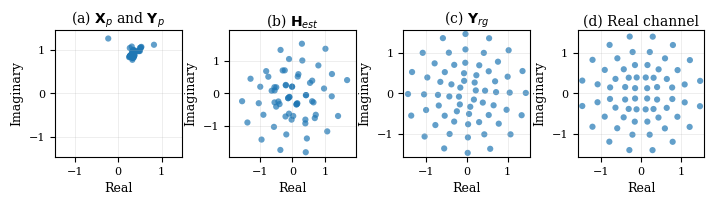

In [ ]:
# IEEE formatting parameters
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Load data
constellation_files = [
    "plots/constellation_model_pilots.npy",
    "plots/constellation_model_hhat.npy",
    "plots/constellation_model_receivedY.npy",
    "plots/constellation_model_baseline.npy"
]

titles = ["(a) $\mathbf{X}_p$ and $\mathbf{Y}_p$", "(b) $\mathbf{H}_{est}$", "(c) $\mathbf{Y}_{rg}$", "(d) Real channel"]

# IEEE double-column width with square subplots
fig, axes = plt.subplots(1, 4, figsize=(7, 2.2))

for idx, (ax, file, title) in enumerate(zip(axes, constellation_files, titles)):
    points = np.load(file)
    maxval = np.max(np.abs(points)) * 1.05
    
    ax.set_xlim(-maxval, maxval)
    ax.set_ylim(-maxval, maxval)
    ax.scatter(np.real(points), np.imag(points), s=20, alpha=0.7, edgecolors='none')
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, which="both", axis="both", linewidth=0.5, alpha=0.3)
    ax.set_title(title, fontsize=10, pad=3)
    ax.set_xlabel("Real", fontsize=9)
    ax.set_ylabel("Imaginary", fontsize=9)
    
    # Tick formatting
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    # Reduce number of ticks for clarity
    ax.locator_params(axis='both', nbins=5)

plt.tight_layout(pad=0.2)
plt.savefig("plots/learned_constellations.png", dpi=300, bbox_inches='tight')
plt.savefig('plots/learned_constellations.eps', format='eps', bbox_inches='tight')
plt.show()